In [ ]:
from glob import glob
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import joblib
from sklearn.metrics import roc_auc_score
import librosa as lb
import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
import tensorflow as tf

# Check if a GPU is available and set it as the device
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"Found {len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        print("GPU is available and configured.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. TensorFlow will use CPU.")

Found 1 Physical GPUs, 1 Logical GPUs
GPU is available and configured.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# IMPORTANT: Replace 'path/to/your/zipfile.zip' with the actual path to your zip file
zip_file_path = '/content/drive/MyDrive/dataset.zip' # Example: '/content/drive/MyDrive/my_data.zip'

# Create a directory to extract files into (optional, but good practice)
extract_dir = './extracted_files'
import os
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file using a shell command
!unzip -q "{zip_file_path}" -d "{extract_dir}"

print(f"Files from {zip_file_path} extracted to {extract_dir}")
!ls {extract_dir}

Files from /content/drive/MyDrive/dataset.zip extracted to ./extracted_files
DEMONSTRATION  KAGGLE


In [ ]:
print('Re-running unzip command to ensure all files are extracted...')
# IMPORTANT: Replace 'path/to/your/zipfile.zip' with the actual path to your zip file
zip_file_path = '/content/drive/MyDrive/dataset.zip' # Example: '/content/drive/MyDrive/my_data.zip'

# Create a directory to extract files into (optional, but good practice)
extract_dir = './extracted_files'
import os
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file using a shell command, forcing overwrite (-o)
!unzip -o -q "{zip_file_path}" -d "{extract_dir}"

print(f"Files from {zip_file_path} extracted to {extract_dir}")
!ls {extract_dir}

Re-running unzip command to ensure all files are extracted...
Files from /content/drive/MyDrive/dataset.zip extracted to ./extracted_files
DEMONSTRATION  KAGGLE


In [ ]:
import os
paths = []
labels = []
# Define the root directory where the labels (FAKE, REAL) are subdirectories
audio_files_path = '/content/extracted_files/KAGGLE/AUDIO' # Corrected path

# Iterate through the label subdirectories (e.g., 'FAKE', 'REAL')
for label_subdir in os.listdir(audio_files_path):
    label_path = os.path.join(audio_files_path, label_subdir)

    # Check if it's a directory (i.e., 'FAKE' or 'REAL')
    if os.path.isdir(label_path):
        # Add all files in the subdirectory
        for filename in os.listdir(label_path):
            file_path = os.path.join(label_path, filename)
            # Ensure it's a file before adding
            if os.path.isfile(file_path):
                paths.append(file_path)
                # The label for this file is the name of the subdirectory ('FAKE' or 'REAL')
                labels.append(label_subdir)

print('Dataset is loaded')
print(f"Found {len(paths)} audio files.")
print(f"First 5 paths: {paths[:5]}")
print(f"First 5 labels: {labels[:5]}")

Dataset is loaded
Found 64 audio files.
First 5 paths: ['/content/extracted_files/KAGGLE/AUDIO/REAL/musk-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/margot-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/trump-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/biden-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/ryan-original.wav']
First 5 labels: ['REAL', 'REAL', 'REAL', 'REAL', 'REAL']


In [ ]:
from glob import glob
import os
folders = os.listdir(audio_files_path)
print(folders)
print('paths:', len(paths))
print('labels:', len(labels))
# Define file paths
real_audio = glob(os.path.join(audio_files_path, 'REAL', '*'))
fake_audio = glob(os.path.join(audio_files_path, 'FAKE', '*'))
real_audio.sort()
fake_audio.sort()
# Display file counts
print(f"Number of real audio samples: {len(real_audio)}")
print(f"Number of fake audio samples: {len(fake_audio)}")

['REAL', 'FAKE']
paths: 64
labels: 64
Number of real audio samples: 8
Number of fake audio samples: 56


In [ ]:
import os
paths = []
labels = []
# Define the root directory where the labels (FAKE, REAL) are subdirectories
audio_files_path = '/content/extracted_files/KAGGLE/AUDIO' # Corrected path

# Iterate through the label subdirectories (e.g., 'FAKE', 'REAL')
for label_subdir in os.listdir(audio_files_path):
    label_path = os.path.join(audio_files_path, label_subdir)

    # Check if it's a directory (i.e., 'FAKE' or 'REAL')
    if os.path.isdir(label_path):
        # Add all files in the subdirectory
        for filename in os.listdir(label_path):
            file_path = os.path.join(label_path, filename)
            # Ensure it's a file before adding
            if os.path.isfile(file_path):
                paths.append(file_path)
                # The label for this file is the name of the subdirectory ('FAKE' or 'REAL')
                labels.append(label_subdir)

print('Dataset is loaded')
print(f"Found {len(paths)} audio files.")
print(f"First 5 paths: {paths[:5]}")
print(f"First 5 labels: {labels[:5]}")

Dataset is loaded
Found 64 audio files.
First 5 paths: ['/content/extracted_files/KAGGLE/AUDIO/REAL/musk-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/margot-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/trump-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/biden-original.wav', '/content/extracted_files/KAGGLE/AUDIO/REAL/ryan-original.wav']
First 5 labels: ['REAL', 'REAL', 'REAL', 'REAL', 'REAL']


In [ ]:
from glob import glob
import os
folders = os.listdir(audio_files_path)
print(folders)
print('paths:', len(paths))
print('labels:', len(labels))
# Define file paths
real_audio = glob(os.path.join(audio_files_path, 'REAL', '*'))
fake_audio = glob(os.path.join(audio_files_path, 'FAKE', '*'))
real_audio.sort()
fake_audio.sort()
# Display file counts
print(f"Number of real audio samples: {len(real_audio)}")
print(f"Number of fake audio samples: {len(fake_audio)}")

['REAL', 'FAKE']
paths: 64
labels: 64
Number of real audio samples: 8
Number of fake audio samples: 56


In [ ]:
real_audio_demo = "/content/extracted_files/DEMONSTRATION/DEMONSTRATION/linus-original-DEMO.mp3"
fake_audio_demo = "/content/extracted_files/DEMONSTRATION/DEMONSTRATION/linus-to-musk-DEMO.mp3"

In [ ]:
import IPython
print("Real audio (Linus Sebastian):")
IPython.display.Audio(filename=real_audio_demo)

Real audio (Linus Sebastian):


In [ ]:
print("DeepFake audio (Linus to Elon Musk):")
IPython.display.Audio(fake_audio_demo)

DeepFake audio (Linus to Elon Musk):


In [ ]:
import numpy as np
import librosa as lb
import matplotlib.pyplot as plt

def get_spectrogram(y: np.ndarray) -> (np.ndarray, tuple):
    '''
    Compute the spectrogram of an audio signal.
    Parameters:
    y (np.ndarray): Audio time series.
    Returns:
    d (np.ndarray): Spectrogram of the audio signal, represented in decib
    shape (tuple): Shape of the spectrogram (number of frequency bins, nu
    '''
    d = lb.stft(y)
    ad = lb.amplitude_to_db(np.abs(d), ref=np.max)
    return ad, ad.shape
def plot_spectrogram(s: np.ndarray, sr: int = 22050, size: tuple=(10, 6), title: str = "Spectrogram of Audio"):
    '''
    Plot a spectrogram.
    Parameters:
    s (np.ndarray): Spectrogram to plot. This should be a 2D array where
    sr (int, optional): Sampling rate of the audio. Default is 22050 Hz.
    size (tuple, optional): Size of the plot as (width, height). Default
    title (str, optional): Title of the plot. Default is "Spectrogram of
    '''
    plt.figure(figsize=size)
    lb.display.specshow(s, x_axis='time', y_axis='mel', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import librosa as lb
import matplotlib.pyplot as plt

def get_mel_spectrogram(y: np.ndarray, sr: int = 22050, n_mels: int = 128):
    '''
    Compute a Mel spectrogram from an audio signal.
    Parameters:
    y (np.ndarray): Audio time series.
    sr (int): Sampling rate of `y`.
    n_mels (int): Number of Mel bands to generate.
    Returns:
    mel_spectrogram (np.ndarray): 2D array representing the Mel spectrogr
    shape (tuple): Shape of the Mel spectrogram (number of Mel bands, num
    '''
    ms = lb.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    m = lb.power_to_db(ms, ref=np.max)
    return m, m.shape

def plot_mel_spectrogram(m: np.ndarray, sr: int = 22050, size: tuple = (10, 6), title: str = "Mel Spectrogram of Audio"):
    '''
    Plot a Mel spectrogram.
    Parameters:
    s (np.ndarray): Mel spectrogram to plot.
    sr (int, optional): Sampling rate of the audio. Default is 22050 Hz.
    size (tuple, optional): Size of the plot as (width, height). Default
    title (str, optional): Title of the plot. Default is "Mel Spectrogram
    '''
    plt.figure(figsize=size)
    lb.display.specshow(m, x_axis='time', y_axis='mel', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# ═══════════════════════════════════════════════════════════════════════
#  GLOBAL COLOUR THEME  —  deep teal / coral / slate
# ═══════════════════════════════════════════════════════════════════════
PALETTE = {
    'bg':        '#0F1923',   # near-black background
    'panel':     '#152030',   # card / subplot background
    'real':      '#00C9A7',   # teal  — Real audio
    'fake':      '#FF6B6B',   # coral — Fake / deepfake audio
    'accent1':   '#4ECDC4',   # lighter teal
    'accent2':   '#FFE66D',   # yellow accent
    'text':      '#E8F4F8',   # near-white text
    'grid':      '#1E3040',   # subtle grid lines
}

# Custom colormaps
CMAP_SPEC = LinearSegmentedColormap.from_list(
    'teal_coral', ['#0F1923', '#00C9A7', '#FFE66D', '#FF6B6B']
)
CMAP_HEAT = LinearSegmentedColormap.from_list(
    'heat_map',  ['#0F1923', '#152030', '#1E5F8A', '#00C9A7', '#FFE66D']
)

# Apply globally
plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['panel'],
    'axes.edgecolor':    PALETTE['grid'],
    'axes.labelcolor':   PALETTE['text'],
    'axes.titlecolor':   PALETTE['text'],
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     10,
    'xtick.color':       PALETTE['text'],
    'ytick.color':       PALETTE['text'],
    'text.color':        PALETTE['text'],
    'grid.color':        PALETTE['grid'],
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'legend.facecolor':  PALETTE['panel'],
    'legend.edgecolor':  PALETTE['grid'],
    'legend.labelcolor': PALETTE['text'],
    'font.family':       'monospace',
    'figure.dpi':        110,
})

BAR_PALETTE = [PALETTE['real'], PALETTE['fake'],
               PALETTE['accent1'], PALETTE['accent2'],
               '#A78BFA', '#F97316']

print("🎨 Global colour theme applied.")

🎨 Global colour theme applied.


Loading sample audio files for analysis...


/tmp/ipykernel_10836/639447026.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_10836/639447026.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


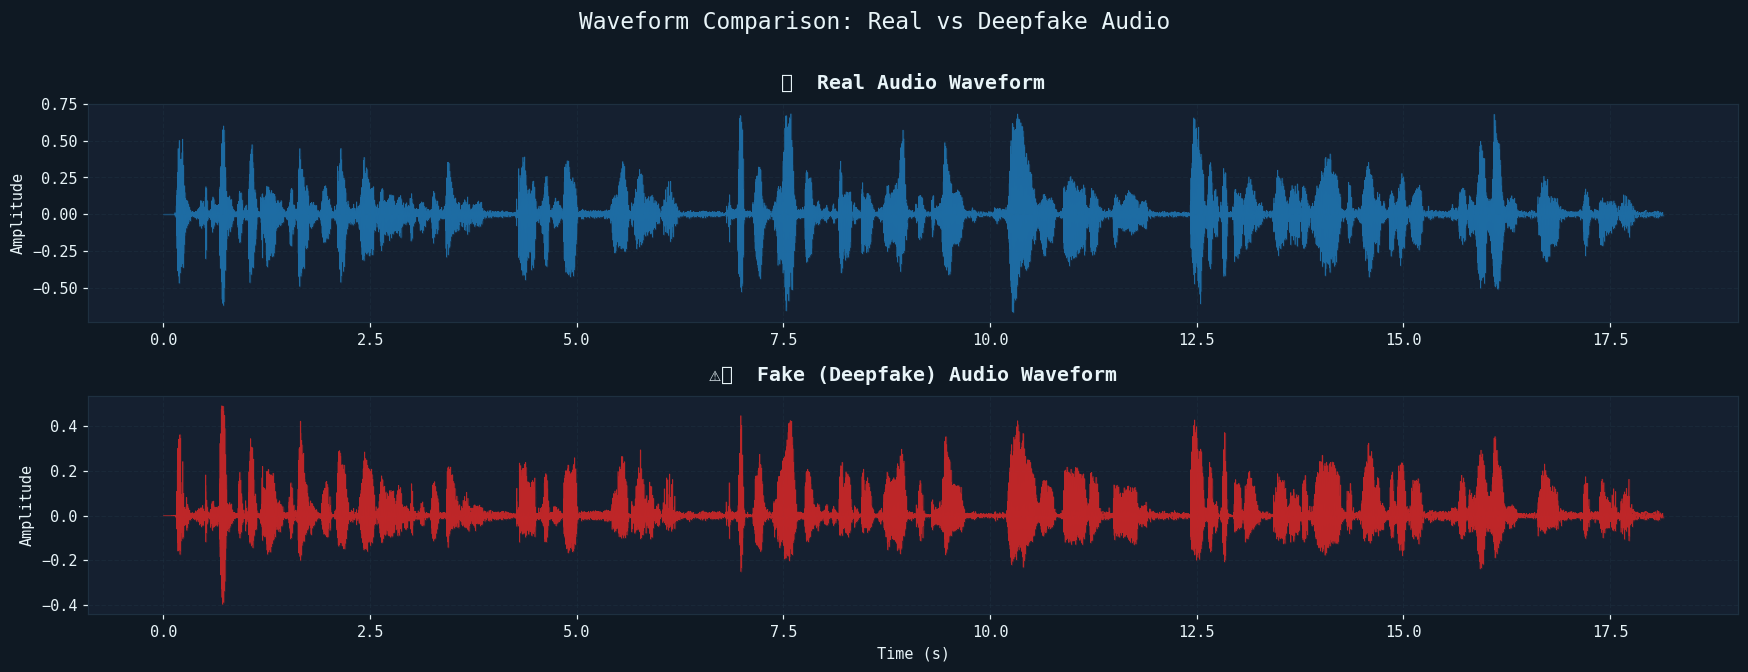

In [ ]:
import numpy as np
import librosa as lb
import matplotlib.pyplot as plt

# Define constants for audio processing and plotting
SR = 22050
CLIP_FRAMES = 400_000  # ~18 seconds

# Map demonstration audio paths to the suggested variable names
DEMO_REAL = real_audio_demo
DEMO_FAKE = fake_audio_demo

# Define a simple color palette for clarity, renamed to avoid conflict
WAVEFORM_PALETTE = {
    'real': '#1f77b4',  # Blue
    'fake': '#d62728'   # Red
}

print("Loading sample audio files for analysis...")

# Load and clip audio using the defined constants
y_real, _ = lb.load(DEMO_REAL, sr=SR)
y_fake, _ = lb.load(DEMO_FAKE, sr=SR)
y_real_clip = y_real[:CLIP_FRAMES]
y_fake_clip = y_fake[:CLIP_FRAMES]

# Waveforms Plotting
ffig, axes = plt.subplots(2, 1, figsize=(16, 6))
# Fix: changed fig.suptitle to ffig.suptitle assuming ffig is the intended Figure object
ffig.suptitle('Waveform Comparison: Real vs Deepfake Audio', fontsize=15, y=1.01)

t = np.linspace(0, len(y_real_clip) / SR, len(y_real_clip))
axes[0].plot(t, y_real_clip, lw=0.4, color=WAVEFORM_PALETTE['real'], alpha=0.85)
axes[0].fill_between(t, y_real_clip, alpha=0.15, color=WAVEFORM_PALETTE['real'])
axes[0].set_title('Real Audio Waveform')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].plot(t, y_fake_clip, lw=0.4, color=WAVEFORM_PALETTE['fake'], alpha=0.85)
axes[1].fill_between(t, y_fake_clip, alpha=0.15, color=WAVEFORM_PALETTE['fake'])
axes[1].set_title('Fake (Deepfake) Audio Waveform')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Generate and plot spectrograms

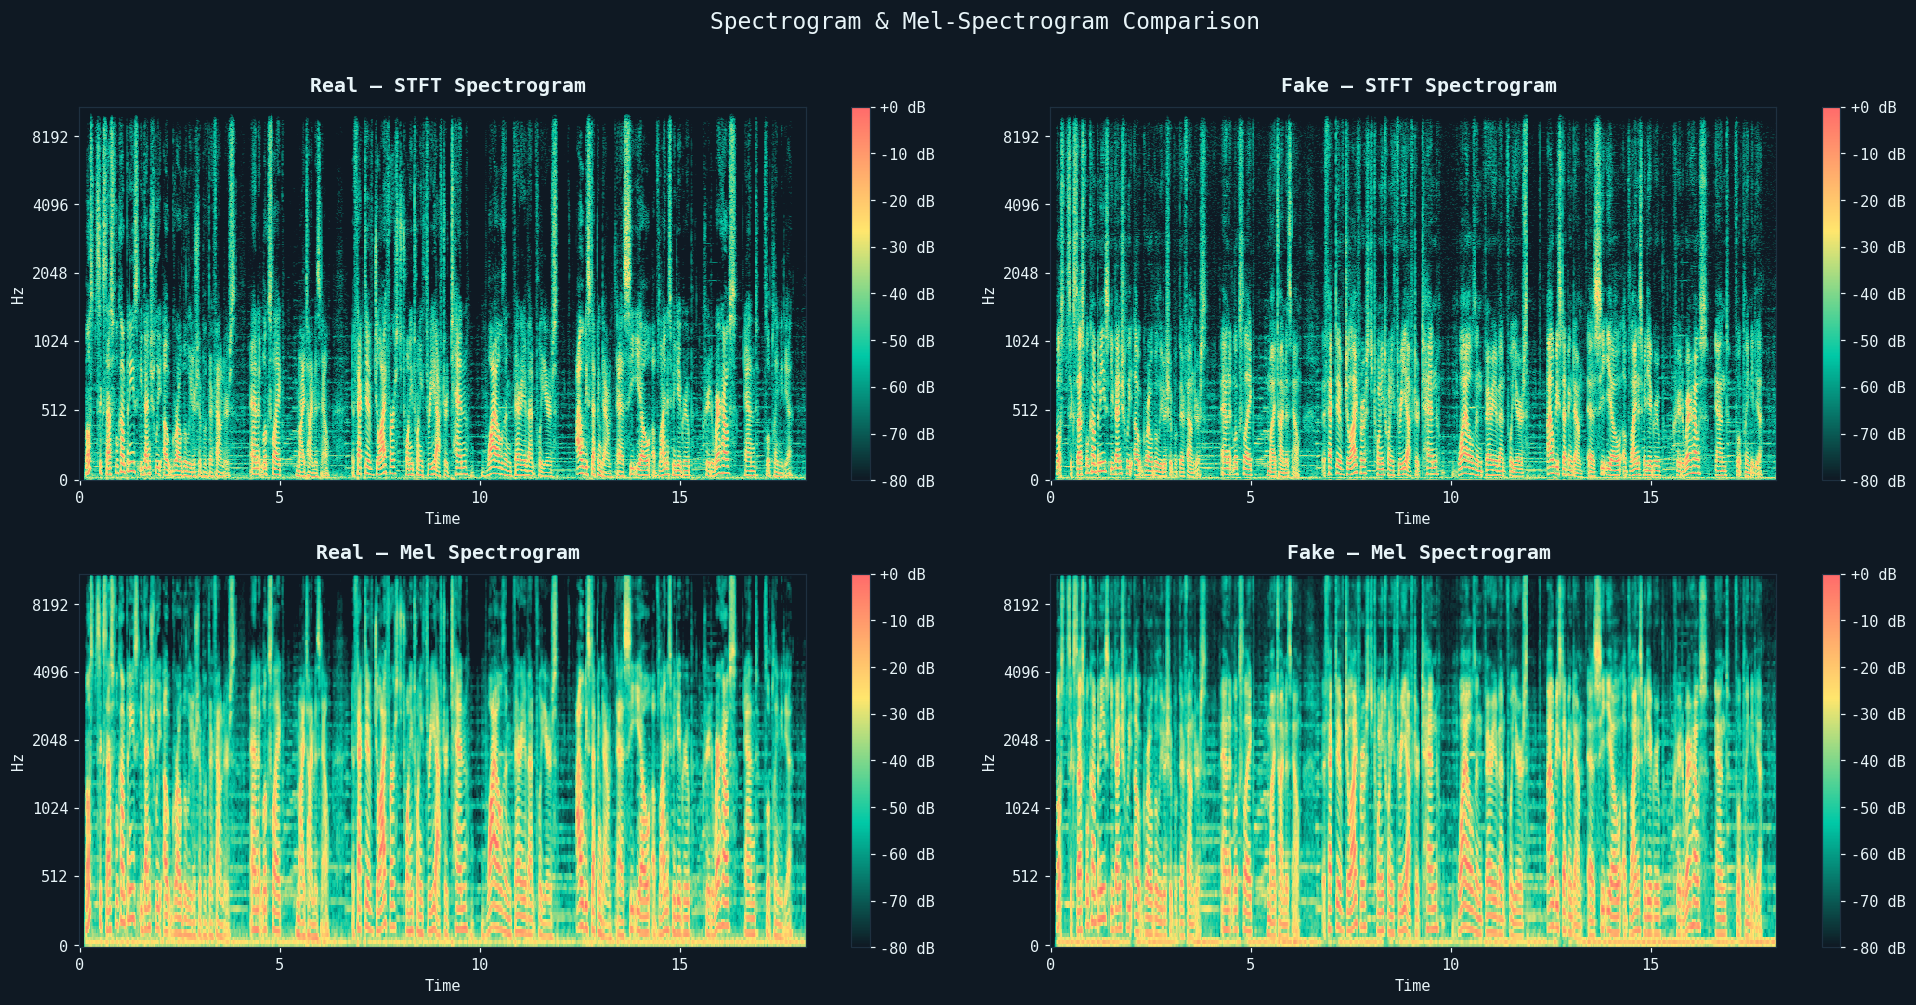

In [ ]:
# ── Spectrogram comparison ────────────────────────────────────────────
def compute_spectrogram(y):
    D  = lb.stft(y)
    dB = lb.amplitude_to_db(np.abs(D), ref=np.max)
    return dB

def compute_mel(y, sr=SR, n_mels=128):
    ms = lb.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    return lb.power_to_db(ms, ref=np.max)

fig, axes = plt.subplots(2, 2, figsize=(18, 9))
fig.suptitle('Spectrogram & Mel-Spectrogram Comparison', fontsize=15, y=1.01)

panels = [
    (compute_spectrogram(y_real_clip), ' Real — STFT Spectrogram',      axes[0, 0]),
    (compute_spectrogram(y_fake_clip), ' Fake — STFT Spectrogram',     axes[0, 1]),
    (compute_mel(y_real_clip),         ' Real — Mel Spectrogram',        axes[1, 0]),
    (compute_mel(y_fake_clip),         ' Fake — Mel Spectrogram',       axes[1, 1]),
]

for data, title, ax in panels:
    img = lb.display.specshow(data, x_axis='time', y_axis='mel',
                               sr=SR, ax=ax, cmap=CMAP_SPEC)
    ax.set_title(title)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.show()

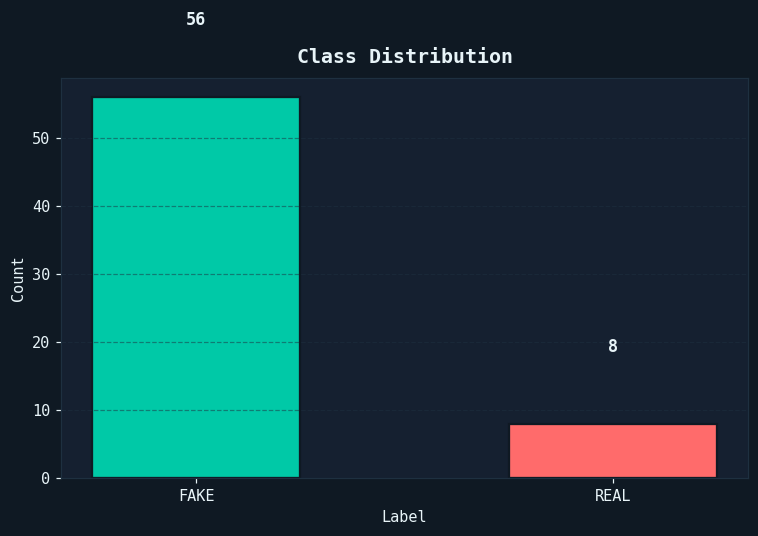

In [ ]:
import pandas as pd
# ── Class distribution ────────────────────────────────────────────────
# Ensure df is defined before use
df = pd.DataFrame()
df['speech'] = paths
df['LABEL'] = labels

vc = df['LABEL'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(vc.index, vc.values,
              color=[PALETTE['real'], PALETTE['fake']],
              edgecolor=PALETTE['bg'], linewidth=1.5,
              width=0.5)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val:,}', ha='center', va='bottom', fontsize=11,
            color=PALETTE['text'], fontweight='bold')
ax.set_title('Class Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

## Generate and plot Mel Spectrogram

Real audio mel spectrogram shape: (12, 782)
Fake audio mel spectrogram shape: (12, 782)


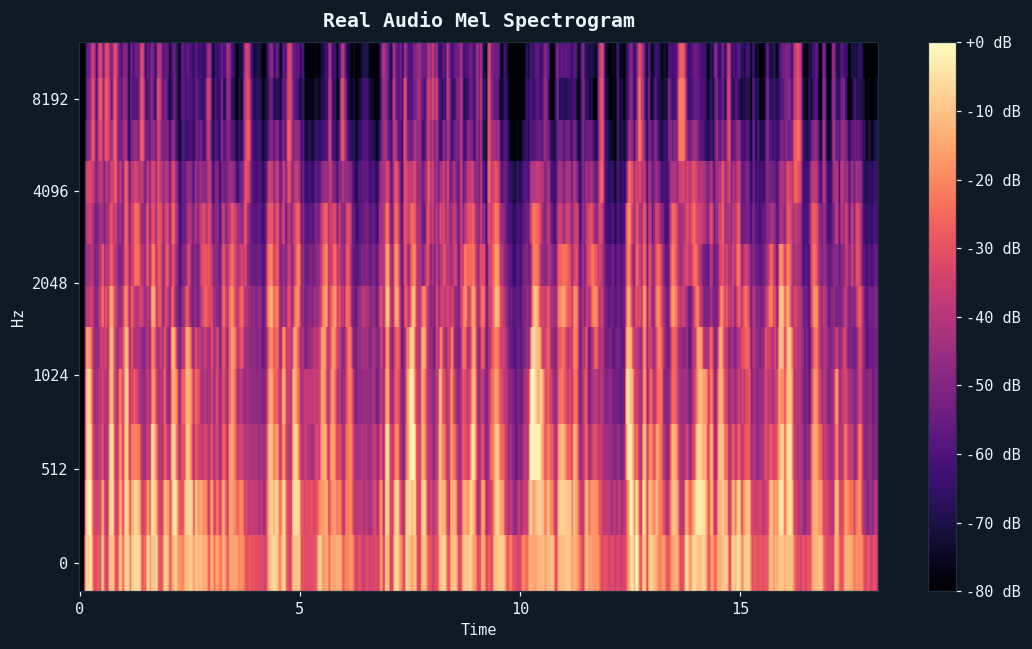

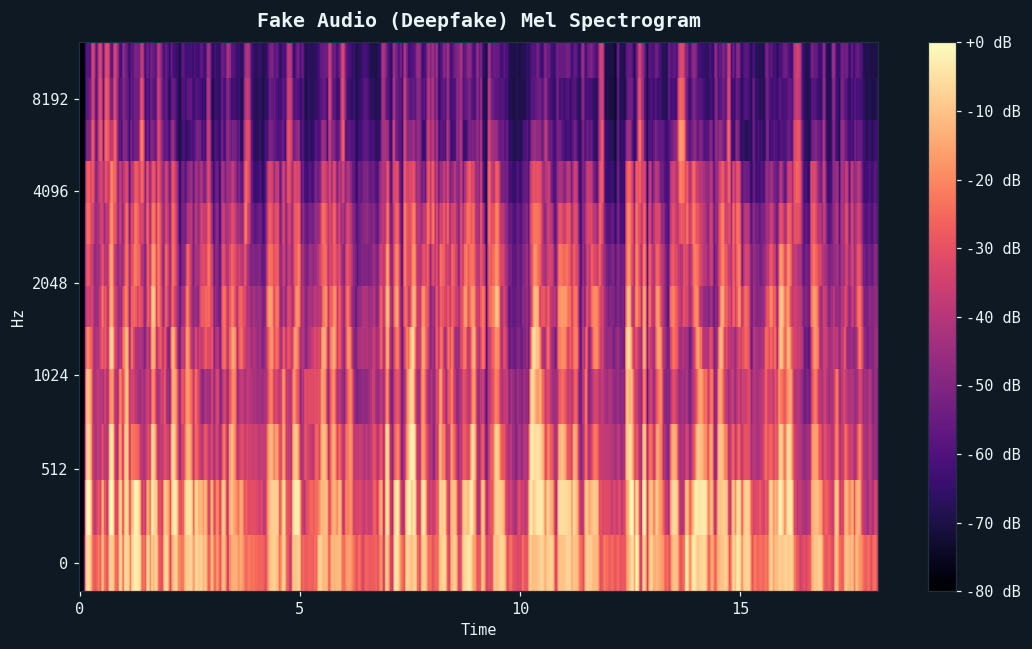

In [ ]:
real_mel, real_mel_shape = get_mel_spectrogram(y_real_clip, n_mels=12)
fake_mel, fake_mel_shape = get_mel_spectrogram(y_fake_clip, n_mels=12)
print(f"Real audio mel spectrogram shape: {real_mel_shape}")
print(f"Fake audio mel spectrogram shape: {fake_mel_shape}")
plot_mel_spectrogram(real_mel, title="Real Audio Mel Spectrogram")
plot_mel_spectrogram(fake_mel, title="Fake Audio (Deepfake) Mel Spectrogram")

# Data Preprocessing

In [ ]:
import pandas as pd
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels

In [ ]:
df['label'].value_counts()

,count
label,
FAKE,56
REAL,8


## Data Augmentation to Handle Data Imbalance
Our dataset is highly imbalanced (56 FAKE vs 8 REAL). To prevent the model from becoming biased towards the majority class, we will generate synthetic examples for the minority class (`REAL`) using audio augmentation techniques such as adding white noise, time stretching, and pitch shifting.

In [ ]:
import soundfile as sf
import librosa as lb
import numpy as np
import os

def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    augmented_data = data + noise_factor * noise
    return augmented_data

def time_stretch(data, rate=0.8):
    return lb.effects.time_stretch(y=data, rate=rate)

def pitch_shift(data, sampling_rate, n_steps=2):
    return lb.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=n_steps)

# Directory to save augmented audio
augmented_dir = '/content/extracted_files/KAGGLE/AUDIO/REAL_AUGMENTED'
os.makedirs(augmented_dir, exist_ok=True)

augmented_real_paths = []

print("Augmenting REAL audio files...")
for file_path in real_audio:
    data, sr = lb.load(file_path)
    base_name = os.path.basename(file_path).replace('.wav', '')

    # 1. Add Noise
    noisy_data = add_noise(data)
    noisy_path = os.path.join(augmented_dir, f"{base_name}_noise.wav")
    sf.write(noisy_path, noisy_data, sr)
    augmented_real_paths.append(noisy_path)

    # 2. Time Stretch (Slow down)
    stretched_data_slow = time_stretch(data, rate=0.85)
    stretch_path_slow = os.path.join(augmented_dir, f"{base_name}_stretch_slow.wav")
    sf.write(stretch_path_slow, stretched_data_slow, sr)
    augmented_real_paths.append(stretch_path_slow)

    # 3. Time Stretch (Speed up)
    stretched_data_fast = time_stretch(data, rate=1.15)
    stretch_path_fast = os.path.join(augmented_dir, f"{base_name}_stretch_fast.wav")
    sf.write(stretch_path_fast, stretched_data_fast, sr)
    augmented_real_paths.append(stretch_path_fast)

    # 4. Pitch Shift (Higher)
    pitched_data_high = pitch_shift(data, sr, n_steps=2)
    pitch_path_high = os.path.join(augmented_dir, f"{base_name}_pitch_high.wav")
    sf.write(pitch_path_high, pitched_data_high, sr)
    augmented_real_paths.append(pitch_path_high)

    # 5. Pitch Shift (Lower)
    pitched_data_low = pitch_shift(data, sr, n_steps=-2)
    pitch_path_low = os.path.join(augmented_dir, f"{base_name}_pitch_low.wav")
    sf.write(pitch_path_low, pitched_data_low, sr)
    augmented_real_paths.append(pitch_path_low)

# Add the augmented paths to our real_audio list
real_audio.extend(augmented_real_paths)

print(f"Generated {len(augmented_real_paths)} augmented REAL audio files.")
print(f"Total REAL audio samples is now: {len(real_audio)}")
print(f"Total FAKE audio samples remains: {len(fake_audio)}")

Augmenting REAL audio files...
Generated 40 augmented REAL audio files.
Total REAL audio samples is now: 48
Total FAKE audio samples remains: 56


## Re-extract Features with Augmented Data
Now that our dataset is more balanced, let's re-extract the Mel spectrogram features for the CNN and RNN models, and the MFCC features for the traditional ML models.

In [ ]:
import time
import random
import numpy as np
import librosa as lb

def get_mel_spectrogram(y: np.ndarray, sr: int = 22050, n_mels: int = 128):
    ms = lb.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    m = lb.power_to_db(ms, ref=np.max)
    return m, m.shape

def create_mel_spectrogram_samples(y: np.ndarray, label: int, sr: int = 22050, samples: int = 10, sample_time: float = 3, n_mels: int = 128):
    start_time = time.time()
    sample_length = int(sr * sample_time)
    s, l = [], []
    if len(y) <= sample_length:
        # Handle short audio by padding and duplicating samples
        y_padded = np.pad(y, (0, sample_length - len(y)), 'constant')
        m, _ = get_mel_spectrogram(y_padded, sr=sr, n_mels=n_mels)
        m = np.abs(m)
        m /= 80
        s.append(m)
        l.append([label])
        for _ in range(samples - 1):
            s.append(m)
            l.append([label])
    else:
        # Generate samples from different parts of the audio
        for _ in range(samples):
            start = random.randint(0, len(y) - sample_length)
            end = start + sample_length
            m, _ = get_mel_spectrogram(y[start:end], sr=sr, n_mels=n_mels)
            m = np.abs(m)
            m /= 80
            s.append(m)
            l.append([label])
    end_time = time.time()
    print(f"...Sample created with label = '{label}' | {samples} samples in {end_time - start_time:.2f} seconds")
    return np.array(s), np.array(l)

print("\nRe-extracting Mel spectrograms for CNN/RNN training...")
# Create balanced dataset with mel spectrograms
n_samples_per_class = 60 # Reduced samples per file to avoid running out of memory
n_mels = 64
sample_duration = 1.5 # seconds
combined_samples_mel = []
combined_labels_mel = []

# Process augmented real audio files (label 0 for real)
# Add a check for real_audio being empty to prevent errors
if real_audio:
    for audio_path in real_audio:
        audio_data, sr = lb.load(audio_path)
        samples, labels = create_mel_spectrogram_samples(
            y=audio_data,
            label=0,
            samples=n_samples_per_class,
            sample_time=sample_duration,
            n_mels=n_mels
        )
        combined_samples_mel.append(samples)
        combined_labels_mel.append(labels)
else:
    print("Warning: 'real_audio' list is empty. No real audio samples will be processed.")

# Process fake audio files (label 1 for fake)
num_fake_to_sample = min(len(fake_audio), len(real_audio)) # This will be 0 if real_audio is empty

if num_fake_to_sample > 0:
    for audio_path in random.sample(fake_audio, k=num_fake_to_sample):
        audio_data, sr = lb.load(audio_path)
        samples, labels = create_mel_spectrogram_samples(
            y=audio_data,
            label=1,
            samples=n_samples_per_class,
            sample_time=sample_duration,
            n_mels=n_mels
        )
        combined_samples_mel.append(samples)
        combined_labels_mel.append(labels)
else:
    print("Warning: No fake audio samples will be processed due to 'num_fake_to_sample' being 0 (likely because 'real_audio' is empty).")

# Combine all spectrogram samples and labels
# Add a check to ensure combined_samples_mel is not empty before concatenating
if combined_samples_mel:
    X_mel_aug = np.concatenate(combined_samples_mel, axis=0)
    y_mel_aug = np.concatenate(combined_labels_mel, axis=0).flatten()

    # Reshape for CNN input: (samples, height, width, channels)
    X_mel_aug = X_mel_aug[..., np.newaxis]
    print(f"Final augmented mel spectrogram data shape: {X_mel_aug.shape}")
    print(f"Final augmented mel spectrogram label shape: {y_mel_aug.shape}")

    # Save for later
    np.save("mel_data_aug.npy", X_mel_aug)
    np.save("mel_labels_aug.npy", y_mel_aug)
else:
    print("Error: No mel spectrogram samples were created. X_mel_aug and y_mel_aug will not be defined.")
    # Initialize with empty arrays of correct dimensions to prevent downstream errors
    # Assuming an expected mel spectrogram shape (e.g., n_mels, timesteps) for a single sample
    # Let's derive it from the `create_mel_spectrogram_samples` function's output if it were to run.
    # For a sample_duration of 1.5s at 22050Hz, sample_length = 33075 frames.
    # librosa.feature.melspectrogram's default hop_length is 512.
    # So, num_timesteps = ceil(sample_length / hop_length) = ceil(33075 / 512) = 65.
    # With n_mels=64, a single mel spectogram would be (64, 65).
    dummy_shape_melspec = (n_mels, int(np.ceil(sample_duration * sr / 512))) # (64, 65)
    X_mel_aug = np.empty((0, *dummy_shape_melspec, 1))
    y_mel_aug = np.empty((0,))
    np.save("mel_data_aug.npy", X_mel_aug)
    np.save("mel_labels_aug.npy", y_mel_aug)




Re-extracting Mel spectrograms for CNN/RNN training...
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.19 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.21 seconds
...Sample created with label = '0' | 60 samples in 0.21 seconds
...Sample created with label = '0' | 60 samples in 0.19 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.19 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples in 0.20 seconds
...Sample created with label = '0' | 60 samples 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before augmentation
labels_before = ['REAL', 'FAKE']
counts_before = [8, 56]
axes[0].bar(labels_before, counts_before, color=['#00C9A7', '#FF6B6B'],
            edgecolor='black', linewidth=1.5)
axes[0].set_title('Before Augmentation (Imbalanced)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Audio Files')
axes[0].set_ylim(0, 70)
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 1.5, str(v), ha='center', fontweight='bold')

# After augmentation
labels_after = ['REAL', 'FAKE']
counts_after = [48, 56]
axes[1].bar(labels_after, counts_after, color=['#00C9A7', '#FF6B6B'],
            edgecolor='black', linewidth=1.5)
axes[1].set_title('After Augmentation (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Audio Files')
axes[1].set_ylim(0, 70)
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 1.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Audio Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Train Enhanced CNN on Augmented Data
Let's load the balanced, augmented dataset we just generated and train our Enhanced CNN on it to see if performance improves and overfitting is reduced.

In [ ]:
# Load the augmented dataset
import numpy as np
from sklearn.model_selection import train_test_split

X_mel_aug = np.load("mel_data_aug.npy")
y_mel_aug = np.load("mel_labels_aug.npy")

# Split the augmented data
X_train_aug, X_temp_aug, y_train_aug, y_temp_aug = train_test_split(
    X_mel_aug, y_mel_aug, test_size=0.3, stratify=y_mel_aug, random_state=42
)
X_val_aug, X_test_aug, y_val_aug, y_test_aug = train_test_split(
    X_temp_aug, y_temp_aug, test_size=0.5, stratify=y_temp_aug, random_state=42
)

# Reshape labels for keras
y_train_aug_tf = tf.cast(y_train_aug.reshape(-1, 1), tf.float32)
y_val_aug_tf = tf.cast(y_val_aug.reshape(-1, 1), tf.float32)
y_test_aug_tf = tf.cast(y_test_aug.reshape(-1, 1), tf.float32)

print(f"Augmented Training set: {X_train_aug.shape}")
print(f"Augmented Validation set: {X_val_aug.shape}")
print(f"Augmented Test set: {X_test_aug.shape}")

Augmented Training set: (4032, 64, 65, 1)
Augmented Validation set: (864, 64, 65, 1)
Augmented Test set: (864, 64, 65, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense, Activation

def build_enhanced_cnn_model(input_shape=(64, 65, 1)):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.2),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.3),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.4),
        Flatten(),
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

# Clear previous session
tf.keras.backend.clear_session()

# Rebuild the enhanced CNN (using the function we defined earlier)
# Assuming input shape is (64, 65, 1)
aug_cnn_model = build_enhanced_cnn_model(input_shape=X_train_aug.shape[1:])

aug_cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)

# Callbacks
aug_early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
aug_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
aug_model_checkpoint = ModelCheckpoint('best_aug_cnn.keras', monitor='val_f1_score_metric', mode='max', save_best_only=True, verbose=1)

print("Training Enhanced CNN on AUGMENTED dataset...")
aug_history = aug_cnn_model.fit(
    X_train_aug,
    y_train_aug_tf,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_aug, y_val_aug_tf),
    callbacks=[aug_early_stopping, aug_reduce_lr, aug_model_checkpoint],
    verbose=1
)

Training Enhanced CNN on AUGMENTED dataset...
Epoch 1/50
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7634 - f1_score_metric: 0.7680 - loss: 0.5001
Epoch 1: val_f1_score_metric improved from None to 0.00000, saving model to best_aug_cnn.keras

Epoch 1: finished saving model to best_aug_cnn.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.8142 - f1_score_metric: 0.8081 - loss: 0.4202 - val_accuracy: 0.5000 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.1720 - learning_rate: 0.0010
Epoch 2/50
123/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8681 - f1_score_metric: 0.8620 - loss: 0.2945
Epoch 2: val_f1_score_metric did not improve from 0.00000
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8837 - f1_score_metric: 0.8815 - loss: 0.2776 - val_accuracy: 0.5000 - val_f1_score_metric: 0.0000e+00 - val_loss: 0.8176 - learning_rate: 0.0010
Epoch 3/50
122/126 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9072 - f1_score_metric: 0.9066 - loss: 0.2215
Epoch 3

In [ ]:
# Evaluate on the augmented test set
print("\nEvaluating Augmented Model on Augmented Test Set:")
aug_loss, aug_accuracy, aug_f1 = aug_cnn_model.evaluate(X_test_aug, y_test_aug_tf)
print(f"Accuracy on Augmented Test Data: {aug_accuracy:.4f}")
print(f"F1 Score on Augmented Test Data: {aug_f1:.4f}")


Evaluating Augmented Model on Augmented Test Set:
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9803 - f1_score_metric: 0.9803 - loss: 0.0586
Accuracy on Augmented Test Data: 0.9803
F1 Score on Augmented Test Data: 0.9803


## Retrain Alternative Models on Augmented Data
Now we will retrain our RNN models (GRU, LSTM) and traditional ML models (SVM, Random Forest) on the balanced, augmented dataset to provide a fair comparison with our Enhanced CNN.

In [ ]:
# 1. Reshape the augmented Mel Spectrograms for RNNs
# Target shape for RNN: (samples, timesteps, features)
X_train_rnn_aug = X_train_aug.squeeze(axis=-1).transpose(0, 2, 1)
X_val_rnn_aug = X_val_aug.squeeze(axis=-1).transpose(0, 2, 1)
X_test_rnn_aug = X_test_aug.squeeze(axis=-1).transpose(0, 2, 1)

print(f"Augmented RNN training set shape: {X_train_rnn_aug.shape}")
print(f"Augmented RNN validation set shape: {X_val_rnn_aug.shape}")
print(f"Augmented RNN test set shape: {X_test_rnn_aug.shape}")

Augmented RNN training set shape: (4032, 65, 64)
Augmented RNN validation set shape: (864, 65, 64)
Augmented RNN test set shape: (864, 65, 64)


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.3),
        GRU(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# 2. Retrain GRU on Augmented Data
tf.keras.backend.clear_session()

gru_model_aug = build_gru_model(input_shape=X_train_rnn_aug.shape[1:])
gru_model_aug.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)

rnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
rnn_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("Training GRU model on augmented data...")
history_gru_aug = gru_model_aug.fit(
    X_train_rnn_aug, y_train_aug_tf,
    batch_size=32,
    epochs=30,
    validation_data=(X_val_rnn_aug, y_val_aug_tf),
    callbacks=[rnn_early_stopping, rnn_reduce_lr],
    verbose=1
)

Training GRU model on augmented data...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5409 - f1_score_metric: 0.5592 - loss: 0.6873 - val_accuracy: 0.5787 - val_f1_score_metric: 0.3659 - val_loss: 0.6778 - learning_rate: 0.0010
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6404 - f1_score_metric: 0.6506 - loss: 0.6344 - val_accuracy: 0.7014 - val_f1_score_metric: 0.6397 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7594 - f1_score_metric: 0.7523 - loss: 0.5318 - val_accuracy: 0.7940 - val_f1_score_metric: 0.7775 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8093 - f1_score_metric: 0.8018 - loss: 0.4427 - val_accuracy: 0.7998 - val_f1_score_metric: 0.8101 - val_loss: 0.4243 - learning_rate: 0.0010
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8378 - f1_score_metric: 0.8323 - loss: 0.3927 - val_accur

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# 3. Retrain LSTM on Augmented Data
tf.keras.backend.clear_session()

lstm_model_aug = build_lstm_model(input_shape=X_train_rnn_aug.shape[1:])
lstm_model_aug.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)

print("\nTraining LSTM model on augmented data...")
history_lstm_aug = lstm_model_aug.fit(
    X_train_rnn_aug, y_train_aug_tf,
    batch_size=32,
    epochs=30,
    validation_data=(X_val_rnn_aug, y_val_aug_tf),
    callbacks=[rnn_early_stopping, rnn_reduce_lr],
    verbose=1
)


Training LSTM model on augmented data...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5675 - f1_score_metric: 0.5824 - loss: 0.6832 - val_accuracy: 0.6134 - val_f1_score_metric: 0.6855 - val_loss: 0.6613 - learning_rate: 0.0010
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6632 - f1_score_metric: 0.6514 - loss: 0.6363 - val_accuracy: 0.6574 - val_f1_score_metric: 0.5556 - val_loss: 0.6265 - learning_rate: 0.0010
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6984 - f1_score_metric: 0.6785 - loss: 0.5933 - val_accuracy: 0.6690 - val_f1_score_metric: 0.5994 - val_loss: 0.6202 - learning_rate: 0.0010
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7133 - f1_score_metric: 0.6945 - loss: 0.5850 - val_accuracy: 0.7188 - val_f1_score_metric: 0.6989 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 5/30
123/126 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7410 - f1_score_metric: 0.7237 - loss: 0.5462
Epoch 5: 

In [ ]:
import time
import random
import numpy as np
import librosa as lb

def create_mfcc_samples(y: np.ndarray, label: int, sr: int = 22050, samples: int = 10,
                        sample_time: float = 3, n_mfcc: int = 13) -> tuple[np.ndarray, np.ndarray]:
    start_time = time.perf_counter()
    sample_length = int(sr * sample_time)
    s, l = [], []

    if len(y) <= sample_length:
        # If audio is shorter than requested sample time, pad with zeros
        y_padded = np.pad(y, (0, sample_length - len(y)), 'constant')
        mfcc = lb.feature.mfcc(y=y_padded, sr=sr, n_mfcc=n_mfcc)
        mfcc_flat = mfcc.flatten()
        # Standardize features
        mfcc_flat = (mfcc_flat - np.mean(mfcc_flat)) / (np.std(mfcc_flat) + 1e-6)
        s.append(mfcc_flat)
        l.append([label])
        # Duplicate to reach requested number of samples
        for _ in range(samples - 1):
            s.append(mfcc_flat)
            l.append([label])
    else:
        for _ in range(samples):
            start = random.randint(0, len(y) - sample_length)
            end = start + sample_length
            mfcc = lb.feature.mfcc(y=y[start:end], sr=sr, n_mfcc=n_mfcc)
            mfcc_flat = mfcc.flatten()
            # Standardize features
            mfcc_flat = (mfcc_flat - np.mean(mfcc_flat)) / (np.std(mfcc_flat) + 1e-6)
            s.append(mfcc_flat)
            l.append([label])
    end_time = time.perf_counter()
    print(f"...Sample created with label = '{label}' | {samples} samples in {end_time - start_time:.2f} seconds")
    return np.array(s), np.array(l)

# 4. Re-extract MFCC features from the augmented dataset for Traditional ML
print("\nExtracting augmented MFCC features for SVM and Random Forest...")
combined_samples_mfcc_aug = []
combined_labels_mfcc_aug = []

# Using 30 samples per audio file to prevent memory issues while ensuring balance
samples_per_file = 30

# Process augmented real audio
for audio_path in real_audio:
    audio_data, sr = lb.load(audio_path)
    samples, labels = create_mfcc_samples(y=audio_data, label=0, samples=samples_per_file, sample_time=3, n_mfcc=20)
    combined_samples_mfcc_aug.append(samples)
    combined_labels_mfcc_aug.append(labels)

# Process fake audio to match the length of augmented real audio
for audio_path in random.sample(fake_audio, k=len(real_audio)):
    audio_data, sr = lb.load(audio_path)
    samples, labels = create_mfcc_samples(y=audio_data, label=1, samples=samples_per_file, sample_time=3, n_mfcc=20)
    combined_samples_mfcc_aug.append(samples)
    combined_labels_mfcc_aug.append(labels)

X_mfcc_aug = np.vstack(combined_samples_mfcc_aug)
y_mfcc_aug = np.vstack(combined_labels_mfcc_aug)
print(f"Augmented MFCC data shape: {X_mfcc_aug.shape}, Labels shape: {y_mfcc_aug.shape}")



Extracting augmented MFCC features for SVM and Random Forest...
...Sample created with label = '0' | 30 samples in 0.24 seconds
...Sample created with label = '0' | 30 samples in 0.35 seconds
...Sample created with label = '0' | 30 samples in 0.39 seconds
...Sample created with label = '0' | 30 samples in 0.30 seconds
...Sample created with label = '0' | 30 samples in 0.22 seconds
...Sample created with label = '0' | 30 samples in 0.22 seconds
...Sample created with label = '0' | 30 samples in 0.23 seconds
...Sample created with label = '0' | 30 samples in 0.23 seconds
...Sample created with label = '0' | 30 samples in 0.22 seconds
...Sample created with label = '0' | 30 samples in 0.25 seconds
...Sample created with label = '0' | 30 samples in 0.23 seconds
...Sample created with label = '0' | 30 samples in 0.23 seconds
...Sample created with label = '0' | 30 samples in 0.24 seconds
...Sample created with label = '0' | 30 samples in 0.22 seconds
...Sample created with label = '0' | 30

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Split the augmented MFCC data
X_train_ml_aug, X_test_ml_aug, y_train_ml_aug, y_test_ml_aug = train_test_split(
    X_mfcc_aug, y_mfcc_aug, test_size=0.3, stratify=y_mfcc_aug, random_state=42
)

# 5. Retrain SVM on Augmented Data
print("\nTraining SVM on augmented data...")
svm_model_aug = svm.SVC(kernel='rbf', C=3)
svm_model_aug.fit(X_train_ml_aug, y_train_ml_aug.ravel())
y_pred_svm_aug = svm_model_aug.predict(X_test_ml_aug)
svm_acc_aug = accuracy_score(y_test_ml_aug.ravel(), y_pred_svm_aug)
svm_f1_aug = f1_score(y_test_ml_aug.ravel(), y_pred_svm_aug)

# 6. Retrain Random Forest on Augmented Data
print("Training Random Forest on augmented data...")
rf_model_aug = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model_aug.fit(X_train_ml_aug, y_train_ml_aug.ravel())
y_pred_rf_aug = rf_model_aug.predict(X_test_ml_aug)
rf_acc_aug = accuracy_score(y_test_ml_aug.ravel(), y_pred_rf_aug)
rf_f1_aug = f1_score(y_test_ml_aug.ravel(), y_pred_rf_aug)

# 7. Evaluate Augmented RNNs
gru_loss_aug, gru_acc_aug, gru_f1_aug = gru_model_aug.evaluate(X_test_rnn_aug, y_test_aug_tf, verbose=0)
lstm_loss_aug, lstm_acc_aug, lstm_f1_aug = lstm_model_aug.evaluate(X_test_rnn_aug, y_test_aug_tf, verbose=0)


Training SVM on augmented data...
Training Random Forest on augmented data...



🏆 Final Model Performance Comparison on Balanced/Augmented Dataset:
| Model                     |   Accuracy |   F1 Score |
|:--------------------------|-----------:|-----------:|
| CNN (Augmented)           |   0.980324 |   0.980347 |
| GRU (Augmented)           |   0.934028 |   0.936737 |
| LSTM (Augmented)          |   0.643519 |   0.71161  |
| SVM (Augmented)           |   0.813657 |   0.806258 |
| Random Forest (Augmented) |   0.836806 |   0.838488 |


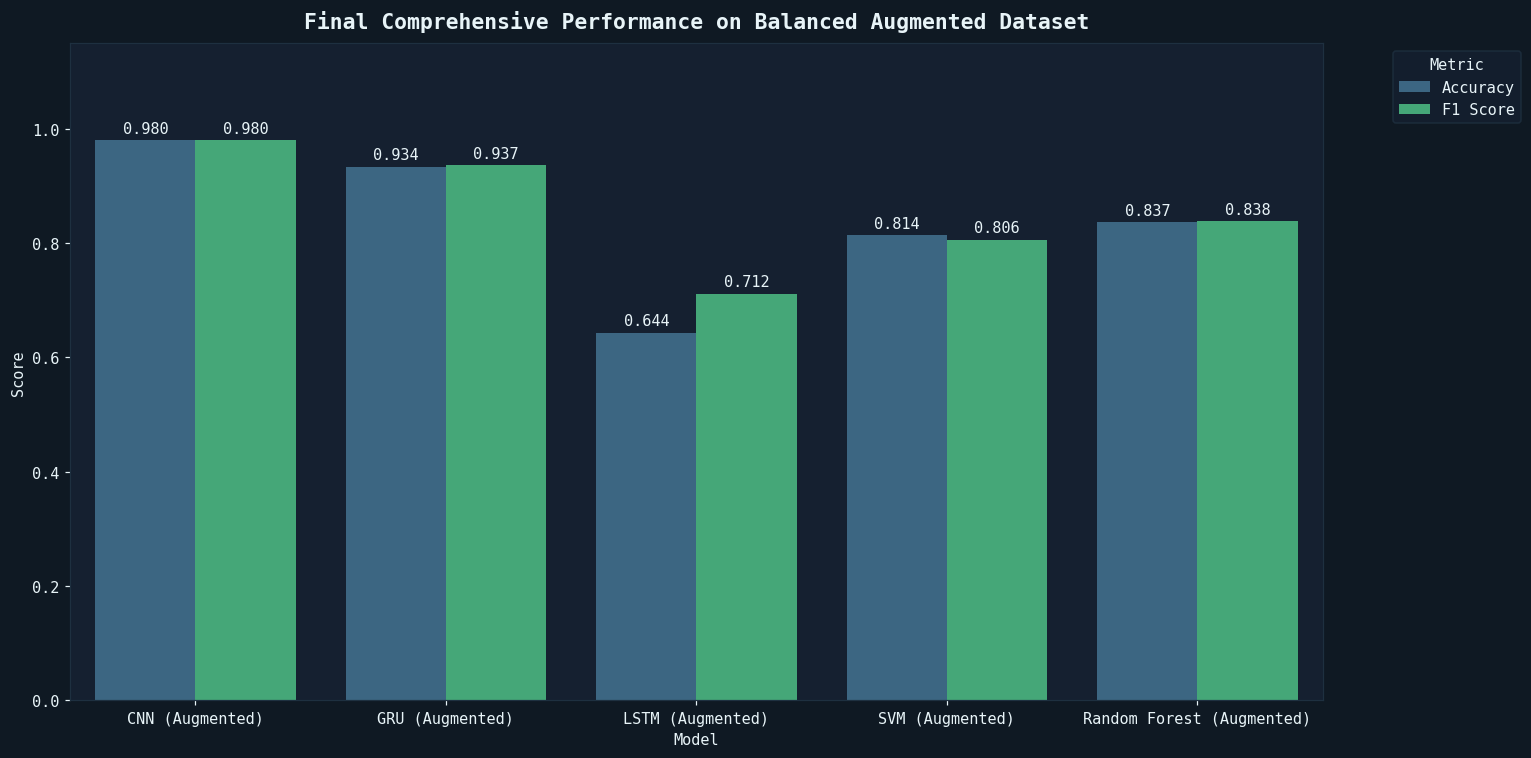

In [ ]:
# 8. Final Comparison on Augmented Dataset
aug_results = pd.DataFrame({
    'Model': ['CNN (Augmented)', 'GRU (Augmented)', 'LSTM (Augmented)', 'SVM (Augmented)', 'Random Forest (Augmented)'],
    'Accuracy': [aug_accuracy, gru_acc_aug, lstm_acc_aug, svm_acc_aug, rf_acc_aug],
    'F1 Score': [aug_f1, gru_f1_aug, lstm_f1_aug, svm_f1_aug, rf_f1_aug]
})

print("\n🏆 Final Model Performance Comparison on Balanced/Augmented Dataset:")
print(aug_results.to_markdown(index=False))

df_melted_aug = aug_results.melt(id_vars=['Model'], var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted_aug, palette='viridis')
plt.title('Final Comprehensive Performance on Balanced Augmented Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3, rotation=0)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Generate multiple mel spectrogram samples from a single
# audio signal



In [ ]:
def create_mel_spectrogram_samples(y: np.ndarray, label: int, sr: int = 22050, samples: int = 10, sample_time: float = 3, n_mels: int = 128):
    '''
    Generate multiple mel spectrogram samples from a single audio signal.
    Parameters:
    y (np.ndarray): The audio signal.
    label (int): The label for the samples (0 for real, 1 for fake).
    sr (int): Sampling rate of the audio signal (default is 22050 Hz).
    samples (int): Number of samples to generate (default is 10).
    sample_time (float): Duration of each sample in seconds (default is 3 seconds).
    n_mels (int): Number of mel frequency bands (default is 128).
    Returns:
    samples (np.ndarray): Array of mel spectrogram samples.
    labels (np.ndarray): Array of labels containing the labels for the corresponding samples.
    '''
    start_time = time.time()
    sample_length = int(sr * sample_time)
    s, l = [], []
    if len(y) <= sample_length:
        # If audio is shorter than requested sample time, pad with zeros
        y_padded = np.pad(y, (0, sample_length - len(y)), 'constant')
        m, _ = get_mel_spectrogram(y_padded, sr=sr, n_mels=n_mels)
        m = np.abs(m)
        m /= 80 # Normalize
        s.append(m)
        l.append([label])
        # Duplicate to reach requested number of samples
        for _ in range(samples - 1):
            s.append(m)
            l.append([label])
    else:
        # Generate samples from different parts of the audio
        for _ in range(samples):
            start = random.randint(0, len(y) - sample_length)
            end = start + sample_length
            m, _ = get_mel_spectrogram(y[start:end], sr=sr, n_mels=n_mels)
            m = np.abs(m)
            m /= 80 # Normalize
            s.append(m)
            l.append([label])
    end_time = time.time()
    print(f"...Sample created with label = '{label}' | {samples} samples in {end_time - start_time:.2f} seconds")
    return np.array(s), np.array(l)

# Create MFCC samples from an audio signal

In [ ]:
def create_mfcc_samples(y: np.ndarray, label: int, sr: int = 22050, samples: int = 10,
                        sample_time: float = 3, n_mfcc: int = 13) -> tuple[np.ndarray, np.ndarray]:
    """
    Create MFCC samples from an audio signal.
    Parameters:
    y (np.ndarray): The input audio signal.
    label (int): The label associated with the audio signal (0 for real,
    sr (int, optional): The sampling rate of the audio signal. Defaults t
    samples (int, optional): The number of samples to generate. Defaults
    sample_time (float, optional): The duration (in seconds) of each samp
    n_mfcc (int, optional): The number of MFCCs to extract. Defaults to 1
    Returns:
    Tuple[np.ndarray, np.ndarray]: A tuple containing:
    - An array of shape (samples, n_mfcc * sample_length) with the MF
    - An array of shape (samples, 1) with the corresponding labels.
    """
    start_time = time.perf_counter()
    sample_length = int(sr * sample_time)
    s, l = [], []

    if len(y) <= sample_length:
        # If audio is shorter than requested sample time, pad with zeros
        y_padded = np.pad(y, (0, sample_length - len(y)), 'constant')
        mfcc = lb.feature.mfcc(y=y_padded, sr=sr, n_mfcc=n_mfcc)
        mfcc_flat = mfcc.flatten()
        # Standardize features
        mfcc_flat = (mfcc_flat - np.mean(mfcc_flat)) / (np.std(mfcc_flat) + 1e-6)
        s.append(mfcc_flat)
        l.append([label])
        # Duplicate to reach requested number of samples
        for _ in range(samples - 1):
            s.append(mfcc_flat)
            l.append([label])
    else:
        for _ in range(samples):
            start = random.randint(0, len(y) - sample_length)
            end = start + sample_length
            mfcc = lb.feature.mfcc(y=y[start:end], sr=sr, n_mfcc=n_mfcc)
            mfcc_flat = mfcc.flatten()
            # Standardize features
            mfcc_flat = (mfcc_flat - np.mean(mfcc_flat)) / (np.std(mfcc_flat) + 1e-6)
            s.append(mfcc_flat)
            l.append([label])
    end_time = time.perf_counter()
    print(f"...Sample created with label = '{label}' | {samples} samples in {end_time - start_time:.2f} seconds")
    return np.array(s), np.array(l)

# Data preparation for CNN approach

In [ ]:
# Data preparation for CNN approach
print("\nPreparing data for CNN training...")
# Create balanced dataset with mel spectrograms
n_samples_per_class = 200
n_mels = 64
sample_duration = 1.5 # seconds
combined_samples_mel = []
combined_labels_mel = []
# Process real audio files (label 0 for real)
for audio_path in real_audio:
    audio_data, sr = lb.load(audio_path)
    samples, labels = create_mel_spectrogram_samples(
        y=audio_data,
        label=0,
        samples=n_samples_per_class,
        sample_time=sample_duration,
        n_mels=n_mels
    )
    combined_samples_mel.append(samples)
    combined_labels_mel.append(labels)
# Process fake audio files (label 1 for fake)
for audio_path in random.sample(fake_audio, k=len(real_audio)): # Balanc
    audio_data, sr = lb.load(audio_path)
    samples, labels = create_mel_spectrogram_samples(
        y=audio_data,
        label=1,
        samples=n_samples_per_class,
        sample_time=sample_duration,
        n_mels=n_mels
    )
    combined_samples_mel.append(samples)
    combined_labels_mel.append(labels)
# Combine all samples
# combined_samples_mel = np.concatenate(combined_samples_mel, axis=0)
# combined_labels_mel = np.concatenate(combined_labels_mel, axis=0)
# # Make sure labels are balanced
# print(f"Total mel spectrogram samples: {combined_samples_mel.shape[0]}"
# print(f"Class distribution: {np.bincount(combined_labels_mel.flatten())}"
# Combine all spectrogram samples and labels
X_mel = np.concatenate(combined_samples_mel, axis=0)
y_mel = np.concatenate(combined_labels_mel, axis=0).flatten()
# Reshape for CNN input: (samples, height, width, channels)
X_mel = X_mel[..., np.newaxis]
print(f"Final mel spectrogram data shape: {X_mel.shape}")
print(f"Final mel spectrogram label shape: {y_mel.shape}")
# Save for later
np.save("mel_data.npy", X_mel)
np.save("mel_labels.npy", y_mel)


Preparing data for CNN training...
...Sample created with label = '0' | 200 samples in 0.67 seconds
...Sample created with label = '0' | 200 samples in 0.65 seconds
...Sample created with label = '0' | 200 samples in 0.64 seconds
...Sample created with label = '0' | 200 samples in 0.66 seconds
...Sample created with label = '0' | 200 samples in 0.66 seconds
...Sample created with label = '0' | 200 samples in 0.66 seconds
...Sample created with label = '0' | 200 samples in 0.66 seconds
...Sample created with label = '0' | 200 samples in 0.66 seconds
...Sample created with label = '0' | 200 samples in 0.68 seconds
...Sample created with label = '0' | 200 samples in 0.67 seconds
...Sample created with label = '0' | 200 samples in 0.68 seconds
...Sample created with label = '0' | 200 samples in 0.67 seconds
...Sample created with label = '0' | 200 samples in 0.66 seconds
...Sample created with label = '0' | 200 samples in 0.72 seconds
...Sample created with label = '0' | 200 samples in 0.

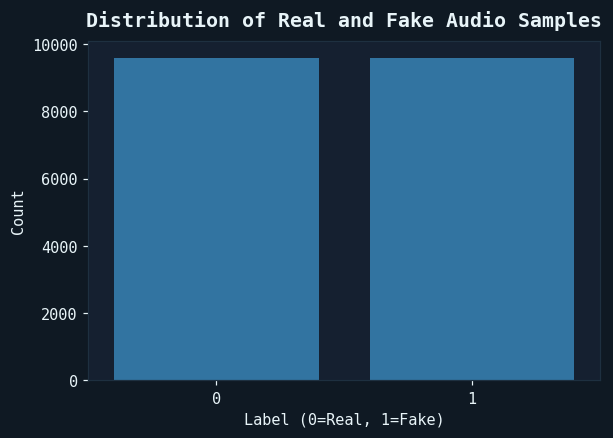

In [ ]:
import seaborn as sns
# Plot sample distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_mel.flatten())
plt.title("Distribution of Real and Fake Audio Samples")
plt.xlabel("Label (0=Real, 1=Fake)")
plt.ylabel("Count")
plt.show()

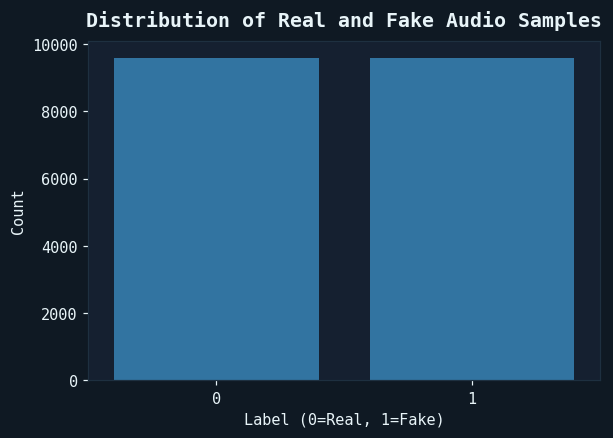

In [ ]:
import seaborn as sns
# Plot sample distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_mel.flatten())
plt.title("Distribution of Real and Fake Audio Samples")
plt.xlabel("Label (0=Real, 1=Fake)")
plt.ylabel("Count")
plt.show()

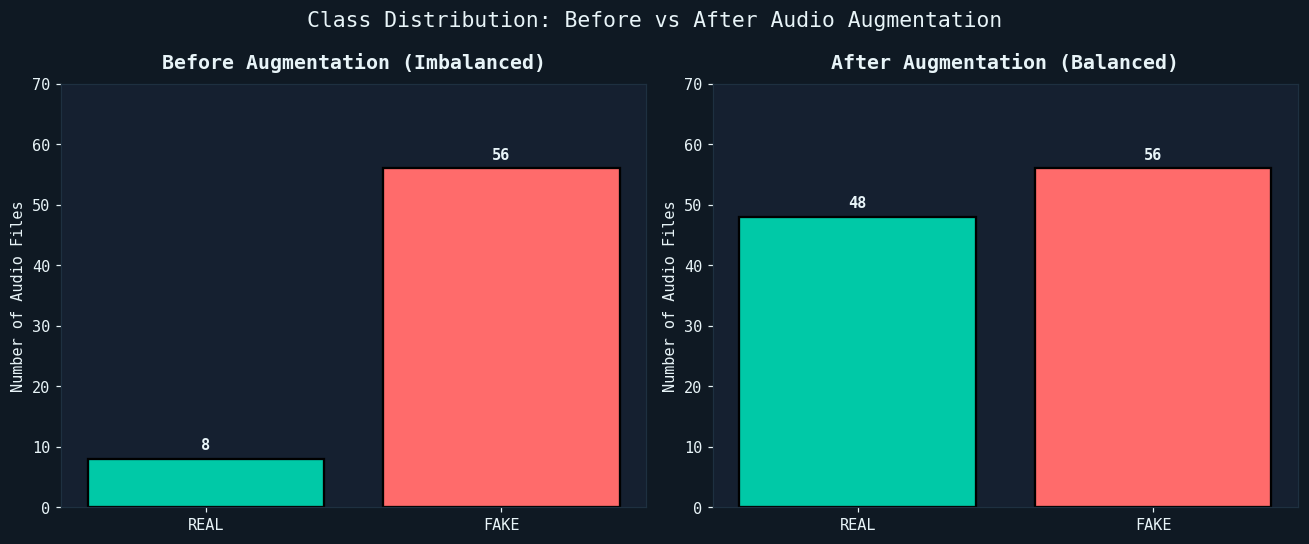

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before augmentation
labels_before = ['REAL', 'FAKE']
counts_before = [8, 56]
axes[0].bar(labels_before, counts_before, color=['#00C9A7', '#FF6B6B'],
            edgecolor='black', linewidth=1.5)
axes[0].set_title('Before Augmentation (Imbalanced)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Audio Files')
axes[0].set_ylim(0, 70)
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 1.5, str(v), ha='center', fontweight='bold')

# After augmentation
labels_after = ['REAL', 'FAKE']
counts_after = [48, 56]
axes[1].bar(labels_after, counts_after, color=['#00C9A7', '#FF6B6B'],
            edgecolor='black', linewidth=1.5)
axes[1].set_title('After Augmentation (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Audio Files')
axes[1].set_ylim(0, 70)
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 1.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Audio Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Data preparation for SVM

In [ ]:
import time # Ensure time is imported in this scope
import random # Ensure random is imported in this scope
import numpy as np # Ensure numpy is imported in this scope

print("\nPreparing MFCC features for traditional ML models...")
# Create dataset with MFCC features
combined_samples_mfcc = []
combined_labels_mfcc = []

processed_real_mfcc_sources_count = 0 # To keep track of how many real audio sources were effectively used for MFCCs

# Process real audio files (label 0 for real)
# Limit the number of files for demonstration purposes, ensuring we have at least one source if real_audio is empty

if real_audio:
    n_real_files_to_process = min(5, len(real_audio))
    print(f"Processing {n_real_files_to_process} real audio files from dataset for MFCCs.")
    for audio_path in real_audio[:n_real_files_to_process]:
        audio_data, sr = lb.load(audio_path)
        samples, labels = create_mfcc_samples(
            y=audio_data,
            label=0,
            samples=100,
            sample_time=3,
            n_mfcc=20
        )
        combined_samples_mfcc.append(samples)
        combined_labels_mfcc.append(labels)
        processed_real_mfcc_sources_count += 1
else:
    print("Warning: No real audio files found in the dataset's 'REAL' directory. Using 'real_audio_demo' as a placeholder for real MFCC samples.")
    audio_data, sr = lb.load(real_audio_demo)
    samples, labels = create_mfcc_samples(
        y=audio_data,
        label=0,
        samples=100, # Generate 100 samples from the demo file
        sample_time=3,
        n_mfcc=20
    )
    combined_samples_mfcc.append(samples)
    combined_labels_mfcc.append(labels)
    processed_real_mfcc_sources_count += 1 # Count the demo as one source

# Determine how many fake audio files to sample to balance with the processed real sources for MFCCs
num_fake_mfcc_to_sample = min(len(fake_audio), processed_real_mfcc_sources_count)
if processed_real_mfcc_sources_count == 0 and len(fake_audio) > 0:
    # Fallback for an unlikely scenario where no real sources were processed but fake ones exist
    num_fake_mfcc_to_sample = min(len(fake_audio), 5)

# Process fake audio files (label 1 for fake)
if num_fake_mfcc_to_sample > 0:
    print(f"Sampling {num_fake_mfcc_to_sample} fake audio files to balance MFCC samples.")
    sampled_fake_audio_mfcc = random.sample(fake_audio, k=num_fake_mfcc_to_sample)
    for audio_path in sampled_fake_audio_mfcc:
        audio_data, sr = lb.load(audio_path)
        samples, labels = create_mfcc_samples(
            y=audio_data,
            label=1,
            samples=100,
            sample_time=3,
            n_mfcc=20
        )
        combined_samples_mfcc.append(samples)
        combined_labels_mfcc.append(labels)
else:
    print("Warning: Not enough fake audio files to sample or no real sources processed for MFCCs. No fake MFCC samples generated.")

# Combine all samples
if combined_samples_mfcc: # Check if the list is not empty before stacking
    X_mfcc = np.vstack(combined_samples_mfcc)
    y_mfcc = np.vstack(combined_labels_mfcc)
    print(f"MFCC data shape: {X_mfcc.shape}, Labels shape: {y_mfcc.shape}")
    # Save if needed
    np.save("mfcc_data.npy", X_mfcc)
    np.save("mfcc_labels.npy", y_mfcc)
else:
    print("Error: No MFCC samples were generated for either real or fake audio. X_mfcc and y_mfcc will be empty.")
    # To prevent downstream errors, create empty arrays with appropriate dimensions if no samples were generated.
    # Assuming n_mfcc = 20 and sample_time = 3 for a reference shape
    # The flatten operation in create_mfcc_samples results in a shape of (n_mfcc * num_time_steps)
    # A single sample's flattened MFCC length can be determined by loading a dummy sample.
    dummy_y_mfcc_single_sample = np.zeros(int(22050 * 3), dtype=np.float32)
    dummy_mfcc = lb.feature.mfcc(y=dummy_y_mfcc_single_sample, sr=22050, n_mfcc=20)
    mfcc_flat_len = dummy_mfcc.flatten().shape[0]

    X_mfcc = np.empty((0, mfcc_flat_len))
    y_mfcc = np.empty((0, 1), dtype=int)
    np.save("mfcc_data.npy", X_mfcc)
    np.save("mfcc_labels.npy", y_mfcc)



Preparing MFCC features for traditional ML models...
Processing 5 real audio files from dataset for MFCCs.
...Sample created with label = '0' | 100 samples in 0.75 seconds
...Sample created with label = '0' | 100 samples in 0.76 seconds
...Sample created with label = '0' | 100 samples in 0.74 seconds
...Sample created with label = '0' | 100 samples in 0.75 seconds
...Sample created with label = '0' | 100 samples in 0.74 seconds
Sampling 5 fake audio files to balance MFCC samples.
...Sample created with label = '1' | 100 samples in 0.75 seconds
...Sample created with label = '1' | 100 samples in 0.97 seconds
...Sample created with label = '1' | 100 samples in 1.33 seconds
...Sample created with label = '1' | 100 samples in 1.05 seconds
...Sample created with label = '1' | 100 samples in 0.76 seconds
MFCC data shape: (1000, 2600), Labels shape: (1000, 1)


# Baseline Model
# Train CNN model

In [ ]:
# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_mel, y_mel, test_size=0.3, stratify=y_mel, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Reshape labels to 2D (needed for FBetaScore)
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Reshape data for CNN (add channel dimension)
# The data is already in the correct 4D format (samples, height, width, channels)
# due to the earlier X_mel = X_mel[..., np.newaxis] step.
X_train_cnn = X_train
X_val_cnn = X_val
X_test_cnn = X_test

print(f"CNN input shape: {X_train_cnn.shape[1:]}")

Training set: (13440, 64, 65, 1)
Validation set: (2880, 64, 65, 1)
Test set: (2880, 64, 65, 1)
CNN input shape: (64, 65, 1)


In [ ]:
cnn_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=X_train_cnn.shape[1:]),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val), epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7589 - loss: 0.4582 - val_accuracy: 0.8764 - val_loss: 0.3102
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8890 - loss: 0.2628 - val_accuracy: 0.8951 - val_loss: 0.2691
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9109 - loss: 0.2150 - val_accuracy: 0.9215 - val_loss: 0.1984
Epoch 4/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9219 - loss: 0.1900 - val_accuracy: 0.9271 - val_loss: 0.1950
Epoch 5/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9316 - loss: 0.1667 - val_accuracy: 0.9031 - val_loss: 0.2415
Epoch 6/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9411 - loss: 0.1515 - val_accuracy: 0.9389 - val_loss: 0.1598
Epoch 7/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9438 - loss: 0.1369 - val_accuracy: 0.9406 - val_loss: 0.1555
Epoch 8/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9524 - loss: 0.1177 - val_accuracy: 0.

# Train SVM model

In [ ]:
# Split data for ML models
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
X_mfcc, y_mfcc, test_size=0.3, stratify=y_mfcc, random_state=42
)
print(f"MFCC features shape: {X_mfcc.shape}")
print(f"ML training set: {X_train_ml.shape}, Test set: {X_test_ml.shape}")
# Train SVM model
print("\nTraining SVM model...")
svm_model = svm.SVC(kernel='rbf', C=3)

MFCC features shape: (1000, 2600)
ML training set: (700, 2600), Test set: (300, 2600)

Training SVM model...


# Base model evaluation
# CNN

In [ ]:
# Predict class probabilities
y_probs = cnn_model.predict(X_test_cnn).ravel()
# Convert probabilities to binary predictions
y_preds = (y_probs > 0.5).astype(int)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score,
  f1_score, roc_auc_score, confusion_matrix, classification_report
)
# Binary classification metrics
accuracy = accuracy_score(y_test, y_preds)
precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
roc_auc_cnn = roc_auc_score(y_test, y_probs)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc_cnn:.4f}")
# Optional: Full classification report
print("\n Classification Report:\n")
print(classification_report(y_test, y_preds))

Accuracy: 0.9497
Precision: 0.9366
Recall: 0.9646
F1 Score: 0.9504
ROC-AUC: 0.9897

 Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1440
           1       0.94      0.96      0.95      1440

    accuracy                           0.95      2880
   macro avg       0.95      0.95      0.95      2880
weighted avg       0.95      0.95      0.95      2880



# ROC curve

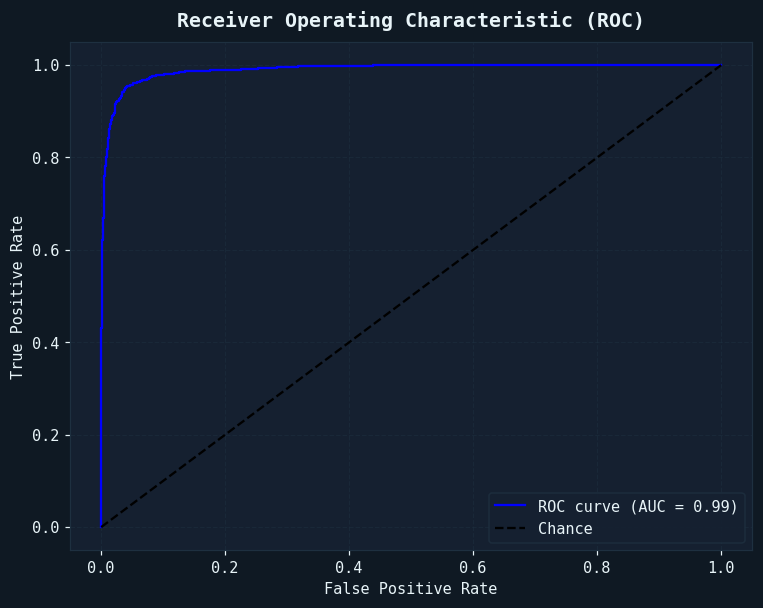

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr, tpr, _= roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_cnn:.2f})", color='b')
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid()
plt.show()

# SVM

ROC-AUC Score: 0.8500
SVM Accuracy: 0.8500
SVM F1 Score: 0.8464


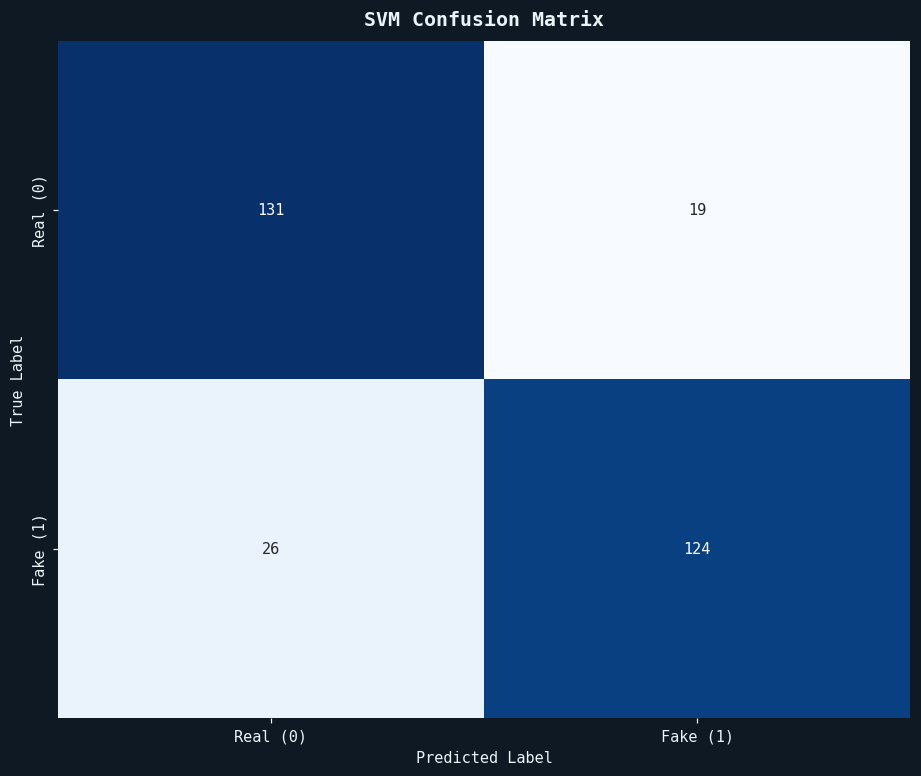

In [ ]:
# Evaluate SVM model
svm_model.fit(X_train_ml, y_train_ml.ravel())
y_pred_svm = svm_model.predict(X_test_ml)
svm_accuracy = accuracy_score(y_test_ml.ravel(), y_pred_svm)
svm_f1 = f1_score(y_test_ml.ravel(), y_pred_svm)
roc_auc = roc_auc_score(y_test_ml.ravel(), y_pred_svm)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"SVM F1 Score: {svm_f1:.4f}")
# Create confusion matrix for SVM
cm_svm = confusion_matrix(y_test_ml.ravel(), y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.yticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.show()

### Cross-Validation for SVM Model

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("\nPerforming cross-validation for SVM model...")
# Use StratifiedKFold to maintain class distribution in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get scores for different metrics
cv_scores = cross_val_score(svm_model, X_mfcc, y_mfcc.ravel(), cv=skf, scoring='f1_weighted')
cv_acc = cross_val_score(svm_model, X_mfcc, y_mfcc.ravel(), cv=skf, scoring='accuracy')
cv_roc = cross_val_score(svm_model, X_mfcc, y_mfcc.ravel(), cv=skf, scoring='roc_auc')

print(f"SVM Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean F1 Score (CV): {cv_scores.mean():.4f}")
print(f"SVM Cross-Validation Accuracy Scores: {cv_acc}")
print(f"Mean Accuracy (CV): {cv_acc.mean():.4f}")
print(f"SVM Cross-Validation ROC AUC Scores: {cv_roc}")
print(f"Mean ROC AUC (CV): {cv_roc.mean():.4f}")


Performing cross-validation for SVM model...
SVM Cross-Validation F1 Scores: [0.85470578 0.86499662 0.86491557 0.84496512 0.8147731 ]
Mean F1 Score (CV): 0.8489
SVM Cross-Validation Accuracy Scores: [0.855 0.865 0.865 0.845 0.815]
Mean Accuracy (CV): 0.8490
SVM Cross-Validation ROC AUC Scores: [0.9344 0.9222 0.9057 0.9438 0.8849]
Mean ROC AUC (CV): 0.9182


# Random Forest


Training Random Forest model...
Random Forest Accuracy: 0.8333
Random Forest F1 Score: 0.8418


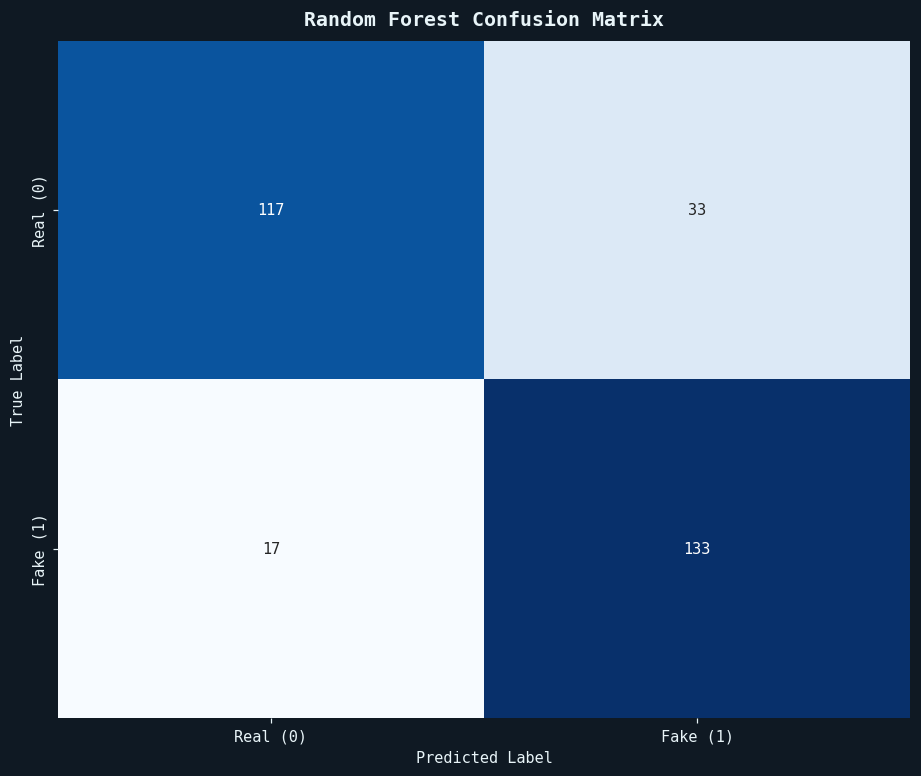

In [ ]:
# Train Random Forest model
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_ml, y_train_ml.ravel())
# Evaluate Random Forest model
y_pred_rf = rf_model.predict(X_test_ml)
rf_accuracy = accuracy_score(y_test_ml.ravel(), y_pred_rf)
rf_f1 = f1_score(y_test_ml.ravel(), y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")
# Create confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test_ml.ravel(), y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.yticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.show()

# Enhanced CNN model with more layers

In [ ]:
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Dropout
import tensorflow as tf # Ensure tf is imported for clear_session

# Define enhanced CNN model with more layers
def build_enhanced_cnn_model(input_shape=(64, 65, 1)):
    model = Sequential([
        # Input layer
        Input(shape=input_shape),
        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.2),
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.3),
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.4),
        # Flatten and dense layers
        Flatten(),
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    return model

# Clear any previous TensorFlow session to prevent graph conflicts
tf.keras.backend.clear_session()

# Build and compile the enhanced CNN model
enhanced_cnn_model = build_enhanced_cnn_model(input_shape=X_train_cnn.shape[1:])
enhanced_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 65, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 65, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 33, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 33, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 33, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 33, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 33, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 17, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,682,337 (10.23 MB)

 Trainable params: 2,680,673 (10.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

# callbacks for training

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
model_checkpoint_acc = ModelCheckpoint(
    'best_model_acc.keras',
    monitor='val_accuracy', #val_accuracy tells you how many predictions
    mode='max',
    save_best_only=True,
    verbose=1
)
model_checkpoint_f1 = ModelCheckpoint(
    'best_model_f1.keras',
    monitor='val_f1_score_metric', # Monitor the named metric
    mode='max',
    save_best_only=True,
    verbose=1
)
# Compile the model
enhanced_cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)

# Train the model with callbacks

In [ ]:
# Convert labels to float32 tensors, which is often required for binary_crossentropy with some metrics
y_train_tf = tf.cast(y_train, tf.float32)
y_val_tf = tf.cast(y_val, tf.float32)

# --- Start of fix ---
# Clear any previous TensorFlow session to prevent graph conflicts, again for robustness
tf.keras.backend.clear_session()

# Rebuild and compile the enhanced CNN model to ensure a clean state
enhanced_cnn_model = build_enhanced_cnn_model(input_shape=X_train_cnn.shape[1:])

# Recompile the model with the Adam optimizer and desired metrics
enhanced_cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)] # Re-added F1Score
)
print("Rebuilt and recompiled enhanced_cnn_model right before training.")
enhanced_cnn_model.summary() # Print summary to confirm shapes
# --- End of fix ---

history = enhanced_cnn_model.fit(
  X_train_cnn,
  y_train_tf, # Use the float32 tensor
  batch_size=32,
  epochs=50,
  validation_data=(X_val_cnn, y_val_tf), # Use the float32 tensor
  callbacks=[early_stopping, reduce_lr, model_checkpoint_acc, model_checkpoint_f1], # Re-added model_checkpoint_f1
  verbose=1
)
# Rename the history object to avoid potential conflicts with previous training histories
enhanced_cnn_history = history

Rebuilt and recompiled enhanced_cnn_model right before training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 65, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 65, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 33, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 33, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 33, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 33, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 33, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 17, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,682,337 (10.23 MB)

 Trainable params: 2,680,673 (10.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

Epoch 1/50
417/420 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8251 - f1_score_metric: 0.8238 - loss: 0.3853
Epoch 1: val_accuracy improved from None to 0.50208, saving model to best_model_acc.keras

Epoch 1: finished saving model to best_model_acc.keras

Epoch 1: val_f1_score_metric improved from None to 0.18057, saving model to best_model_f1.keras

Epoch 1: finished saving model to best_model_f1.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8700 - f1_score_metric: 0.8684 - loss: 0.3009 - val_accuracy: 0.5021 - val_f1_score_metric: 0.1806 - val_loss: 1.0772 - learning_rate: 0.0010
Epoch 2/50
417/420 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9217 - f1_score_metric: 0.9224 - loss: 0.1940
Epoch 2: val_accuracy improved from 0.50208 to 0.79410, saving model to best_model_acc.keras

Epoch 2: finished saving model to best_model_acc.keras

Epoch 2: val_f1_score_metric improved from 0.18057 to 0.75302, saving model to best_model_f1.keras

Epoch 2: finished saving mode

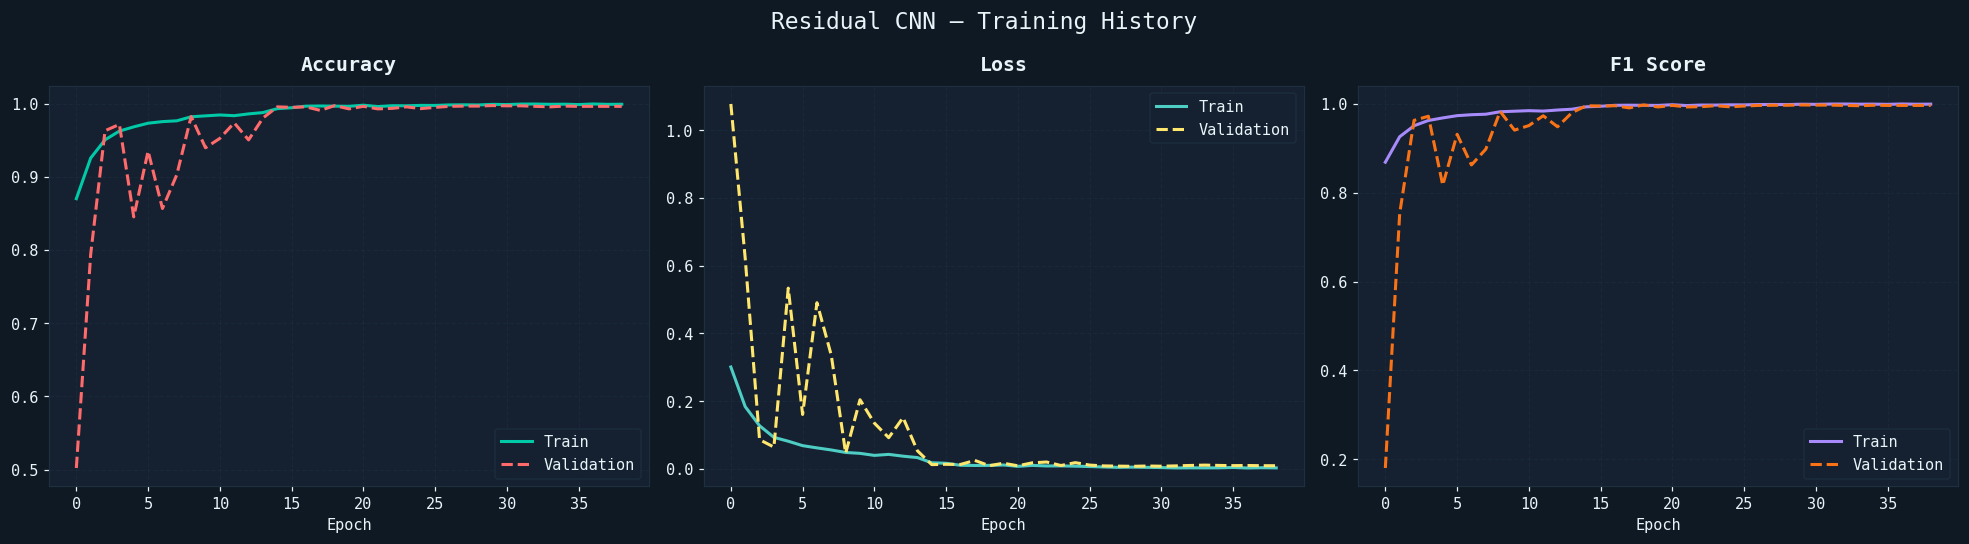

In [ ]:
# ── Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual CNN — Training History', fontsize=15)

metrics_plot = [
    ('accuracy',   'val_accuracy',   'Accuracy',  PALETTE['real'],   PALETTE['fake']),
    ('loss',       'val_loss',       'Loss',      PALETTE['accent1'], PALETTE['accent2']),
    ('f1_score_metric',   'val_f1_score_metric',   'F1 Score',  '#A78BFA',         '#F97316'),
]

for ax, (tr_key, val_key, title, c_tr, c_val) in zip(axes, metrics_plot):
    ax.plot(history.history[tr_key],  label='Train',      color=c_tr,  lw=2)
    ax.plot(history.history[val_key], label='Validation', color=c_val, lw=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Training Results
# best model (on validation) generalizes well on unseen test data

In [ ]:
best_model_f1 = load_model('best_model_f1.keras', compile=False)
best_model_acc = load_model('best_model_acc.keras', compile=False)
# Compile again if needed
metrics = ['accuracy', tf.keras.metrics.F1Score(threshold=0.5)]
best_model_f1.compile(optimizer='adam', loss='binary_crossentropy', metrics=metrics)
best_model_acc.compile(optimizer='adam', loss='binary_crossentropy', metrics=metrics)
# Evaluate on test set
print(" Evaluating Best F1 Model:")
f1_loss, f1_acc, f1_score = best_model_f1.evaluate(X_test_cnn, y_test)
print("\n Evaluating Best Accuracy Model:")
acc_loss, acc_acc, acc_f1_score = best_model_acc.evaluate(X_test_cnn, y_test)

 Evaluating Best F1 Model:
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9941 - f1_score: 0.9941 - loss: 0.0208

 Evaluating Best Accuracy Model:
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9899 - f1_score: 0.9920 - loss: 0.0254


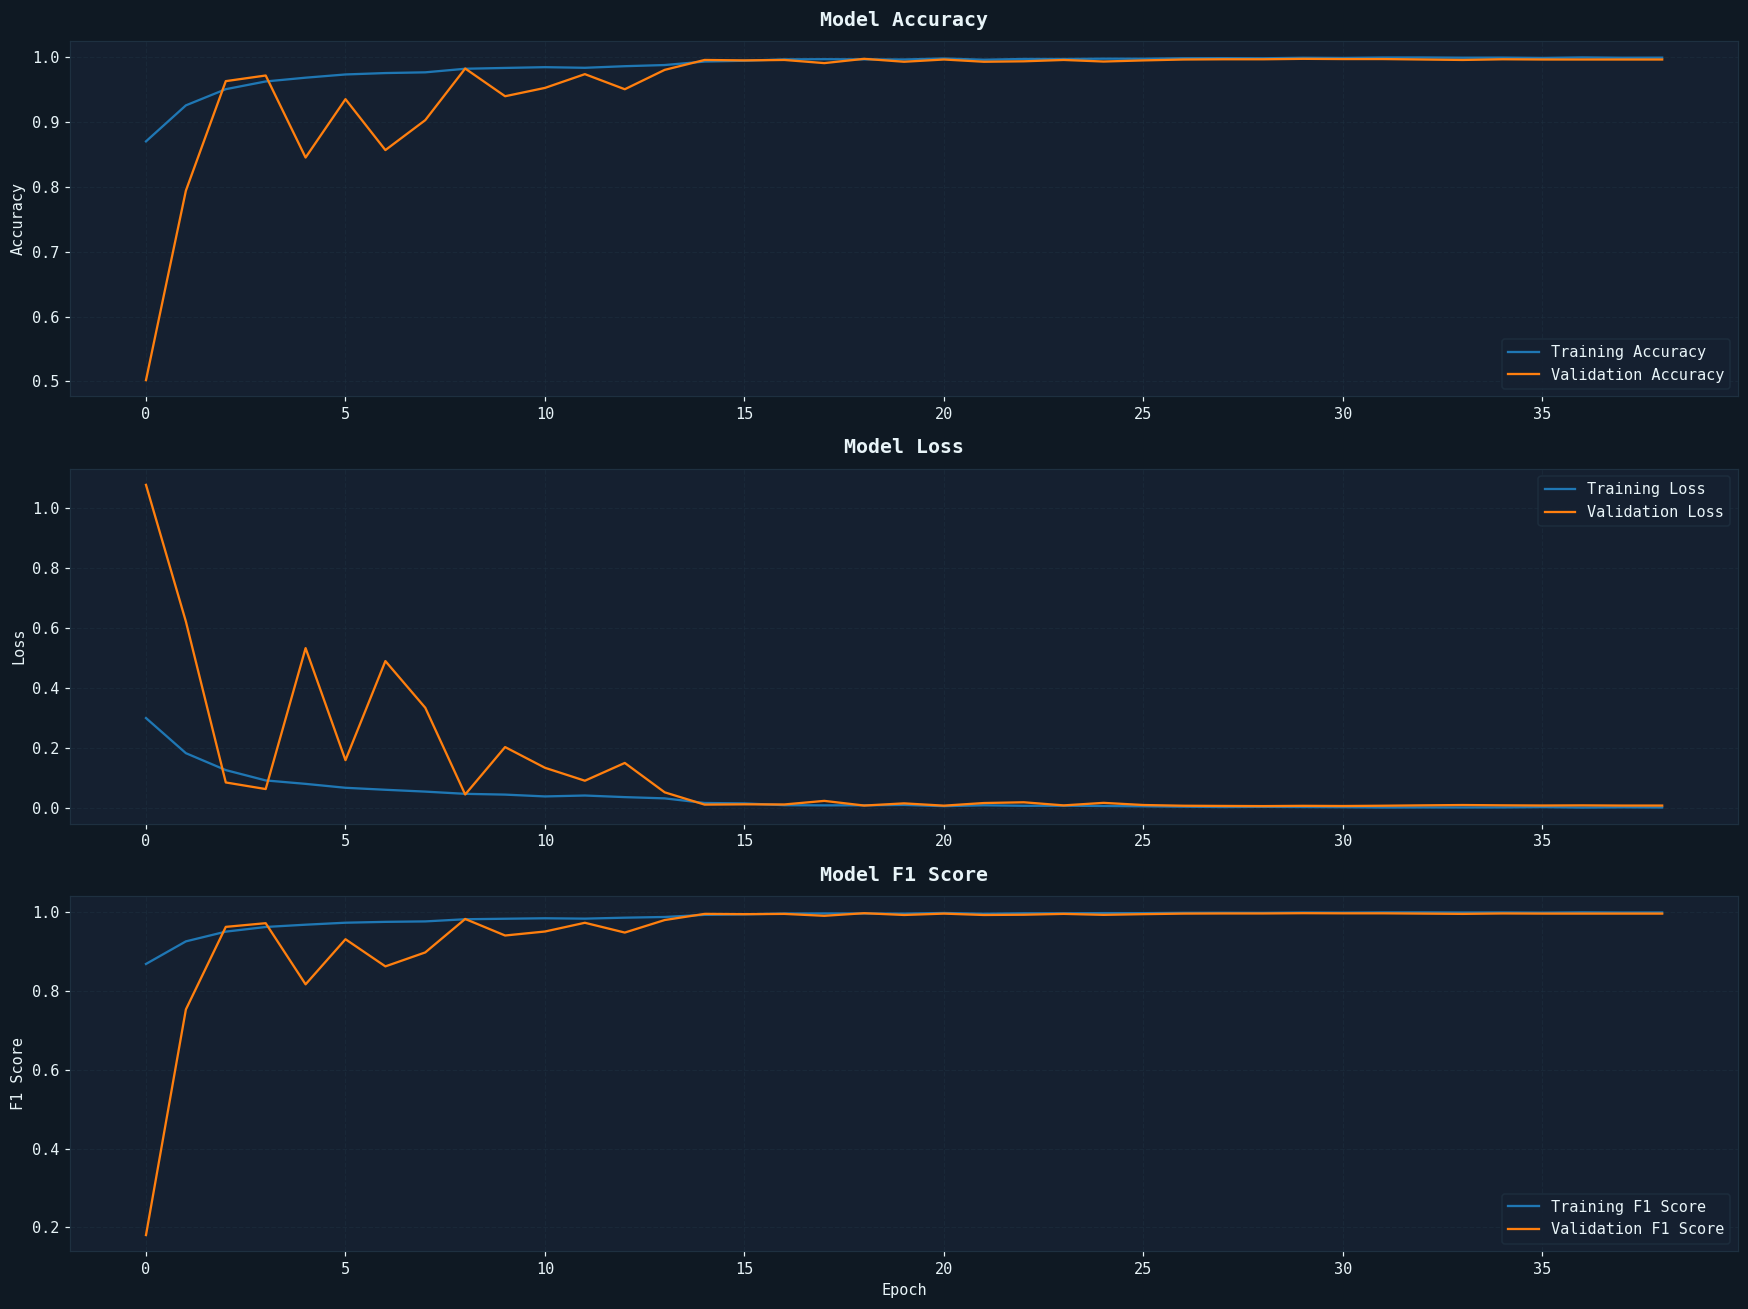

In [ ]:
# Plot training history
plt.figure(figsize=(16, 12))
plt.subplot(3, 1, 1)
plt.plot(enhanced_cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(enhanced_cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(3, 1, 2)
plt.plot(enhanced_cnn_history.history['loss'], label='Training Loss')
plt.plot(enhanced_cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.subplot(3, 1, 3)
# Check if 'f1_score_metric' exists before plotting
if 'f1_score_metric' in enhanced_cnn_history.history and 'val_f1_score_metric' in enhanced_cnn_history.history:
    plt.plot(enhanced_cnn_history.history['f1_score_metric'], label='Training F1 Score')
    plt.plot(enhanced_cnn_history.history['val_f1_score_metric'], label='Validation F1 Score')
    plt.title('Model F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
else:
    plt.title('Model F1 Score (Not available)')
    plt.text(0.5, 0.5, 'F1 Score metric data missing', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

# Model evaluation

## Cross-Validation for Enhanced CNN Model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import clone_model
import gc # Garbage Collector

print("\nPerforming Stratified K-Fold Cross-Validation for Enhanced CNN model...")

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
cnn_cv_accuracy_scores = []
cnn_cv_f1_scores = []
cnn_cv_roc_auc_scores = []

# Ensure the input shape is consistent
input_shape = X_mel.shape[1:]

for fold, (train_index, val_index) in enumerate(skf.split(X_mel, y_mel)):
    print(f"\n--- Fold {fold + 1}/{skf.n_splits} ---")

    # Split data for current fold
    X_train_fold, X_val_fold = X_mel[train_index], X_mel[val_index]
    # Reshape labels to 2D for Keras metrics, which expect (batch_size, output_dim)
    y_train_fold, y_val_fold = y_mel[train_index].reshape(-1, 1), y_mel[val_index].reshape(-1, 1)

    # Rebuild and compile the model for each fold to ensure independent training
    # The build_enhanced_cnn_model function is already defined earlier.
    fold_model = build_enhanced_cnn_model(input_shape=input_shape)

    fold_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
    )

    # Define callbacks for this fold
    fold_early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )
    fold_reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    # Train the model
    history_fold = fold_model.fit(
        X_train_fold,
        y_train_fold,
        batch_size=32,
        epochs=50,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[fold_early_stopping, fold_reduce_lr],
        verbose=0 # Suppress verbose output for cleaner CV printing
    )

    # Evaluate the model on the validation set of the current fold
    val_loss, val_accuracy, val_f1_score = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Predict probabilities for ROC AUC calculation
    y_pred_prob_fold = fold_model.predict(X_val_fold, verbose=0).ravel()
    roc_auc_fold = roc_auc_score(y_val_fold, y_pred_prob_fold)

    cnn_cv_accuracy_scores.append(val_accuracy)
    cnn_cv_f1_scores.append(val_f1_score)
    cnn_cv_roc_auc_scores.append(roc_auc_fold)

    print(f"Fold {fold + 1} - Validation Accuracy: {val_accuracy:.4f}, F1 Score: {val_f1_score:.4f}, ROC AUC: {roc_auc_fold:.4f}")

    # Clear TensorFlow session and collect garbage to free up memory
    tf.keras.backend.clear_session()
    del fold_model
    gc.collect()

print("\n--- Cross-Validation Results for Enhanced CNN ---")
print(f"Average Accuracy: {np.mean(cnn_cv_accuracy_scores):.4f} (+/- {np.std(cnn_cv_accuracy_scores):.4f})")
print(f"Average F1 Score: {np.mean(cnn_cv_f1_scores):.4f} (+/- {np.std(cnn_cv_f1_scores):.4f})")
print(f"Average ROC AUC: {np.mean(cnn_cv_roc_auc_scores):.4f} (+/- {np.std(cnn_cv_roc_auc_scores):.4f})")


Performing Stratified K-Fold Cross-Validation for Enhanced CNN model...

--- Fold 1/5 ---
Fold 1 - Validation Accuracy: 0.9909, F1 Score: 0.9909, ROC AUC: 0.9998

--- Fold 2/5 ---
Fold 2 - Validation Accuracy: 0.9932, F1 Score: 0.9932, ROC AUC: 0.9998

--- Fold 3/5 ---
Fold 3 - Validation Accuracy: 0.9951, F1 Score: 0.9950, ROC AUC: 0.9999

--- Fold 4/5 ---
Fold 4 - Validation Accuracy: 0.9974, F1 Score: 0.9974, ROC AUC: 1.0000

--- Fold 5/5 ---
Fold 5 - Validation Accuracy: 0.9969, F1 Score: 0.9969, ROC AUC: 0.9999

--- Cross-Validation Results for Enhanced CNN ---
Average Accuracy: 0.9947 (+/- 0.0024)
Average F1 Score: 0.9947 (+/- 0.0024)
Average ROC AUC: 0.9999 (+/- 0.0001)


## Updated Model Comparison with CNN Cross-Validation


Updated Model Comparison:
| Model                        |   Accuracy |   F1 Score |   ROC AUC |
|:-----------------------------|-----------:|-----------:|----------:|
| SVM (Test)                   |   0.85     |   0.846416 |  0.85     |
| SVM (CV Avg)                 |   0.849    |   0.848871 |  0.9182   |
| CNN (Best Model on Test Set) |   0.994097 |   0.994066 |  0.98966  |
| CNN (CV Avg)                 |   0.994687 |   0.994679 |  0.999865 |


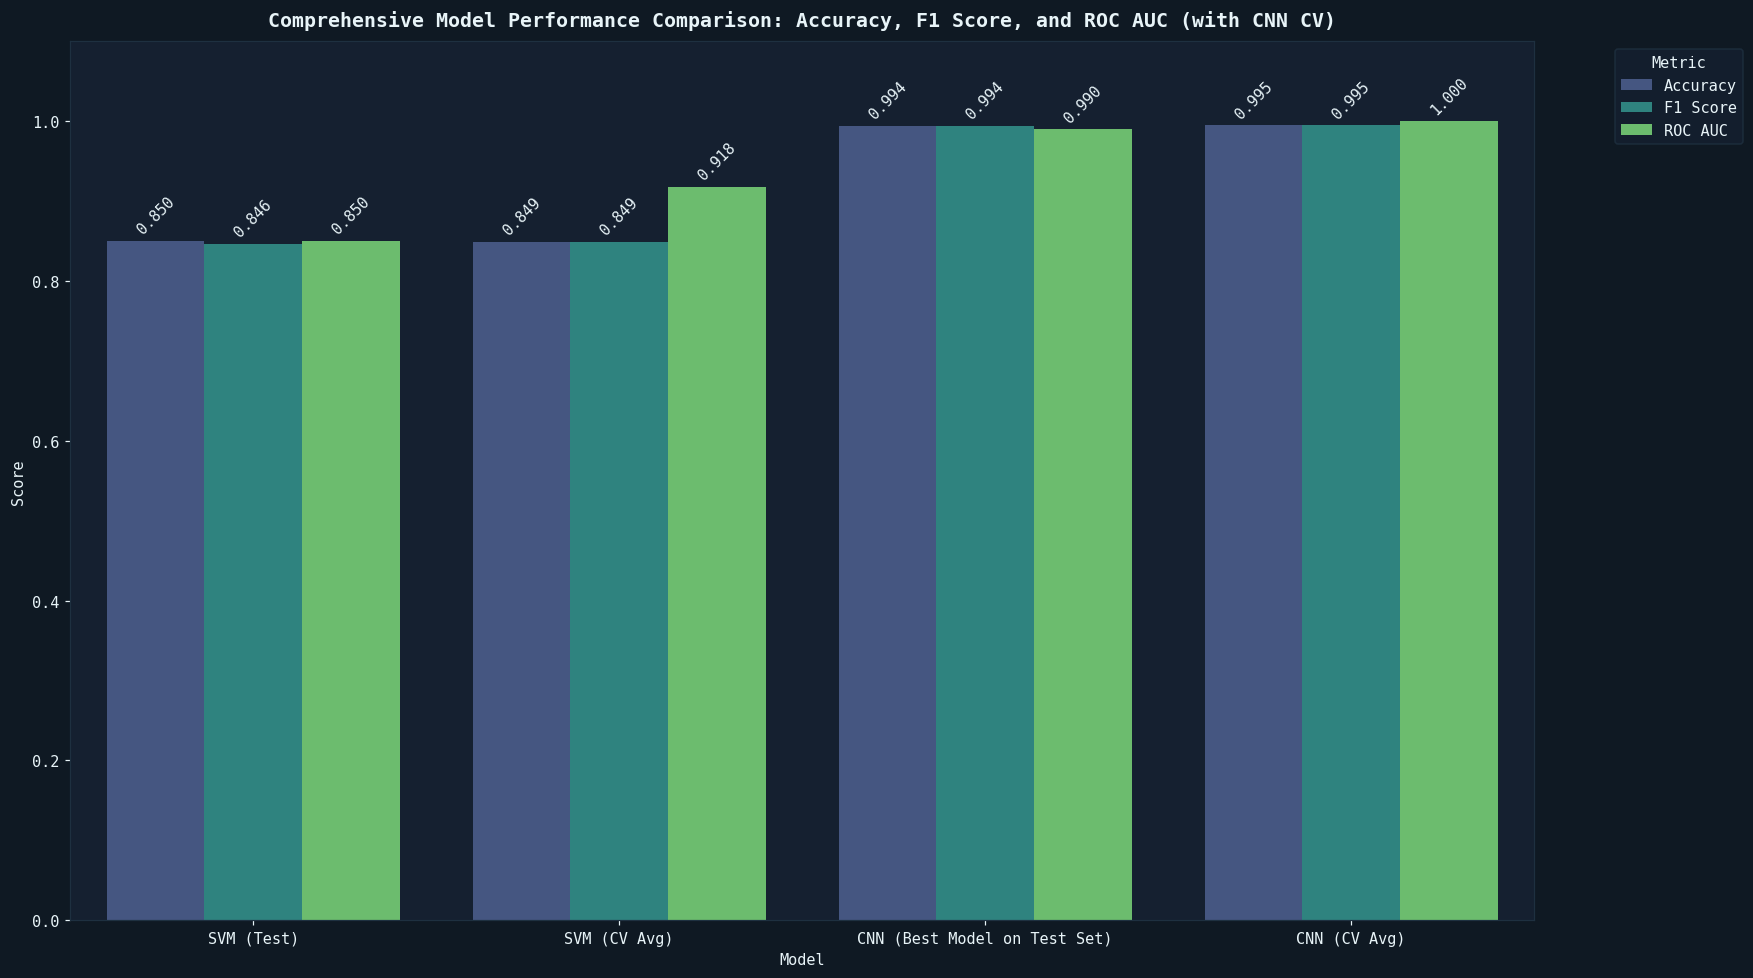

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best CNN model (from best_model_f1.keras) and evaluate to get cnn_metrics
# This code was moved from UGYBZTqYsMV3 to ensure cnn_metrics is defined
best_cnn_model = tf.keras.models.load_model("best_model_f1.keras", compile=False)
best_cnn_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy', tf.keras.metrics.F1Score(threshold=0.5)])
cnn_metrics = best_cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

updated_results = {
    "Model": [
        "SVM (Test)", "SVM (CV Avg)",
        "CNN (Best Model on Test Set)",
        "CNN (CV Avg)"
    ],
    "Accuracy": [
        svm_accuracy, cv_acc.mean(),
        cnn_metrics[1], # From the single test set evaluation
        np.mean(cnn_cv_accuracy_scores)
    ],
    "F1 Score": [
        svm_f1, cv_scores.mean(),
        cnn_metrics[2], # From the single test set evaluation
        np.mean(cnn_cv_f1_scores)
    ],
    "ROC AUC": [
        roc_auc, cv_roc.mean(),
        roc_auc_cnn, # From the single test set evaluation
        np.mean(cnn_cv_roc_auc_scores)
    ]
}

df_updated_results = pd.DataFrame(updated_results)
print("\nUpdated Model Comparison:")
print(df_updated_results.to_markdown(index=False))

# Visualize the updated comparison
df_melted_updated = df_updated_results.melt(id_vars=['Model'], var_name='Metric', value_name='Value')

plt.figure(figsize=(16, 9))
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted_updated, palette='viridis')
plt.title('Comprehensive Model Performance Comparison: Accuracy, F1 Score, and ROC AUC (with CNN CV)')
plt.ylabel('Score')
plt.ylim(0, 1.1) # Extend y-limit slightly above 1 for labels

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3, rotation=45)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Evaluating model on test set...
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9941 - f1_score_metric: 0.9941 - loss: 0.0208
Test Loss: 0.0208
Test Accuracy: 0.9941
Test F1 Score: 0.9941
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


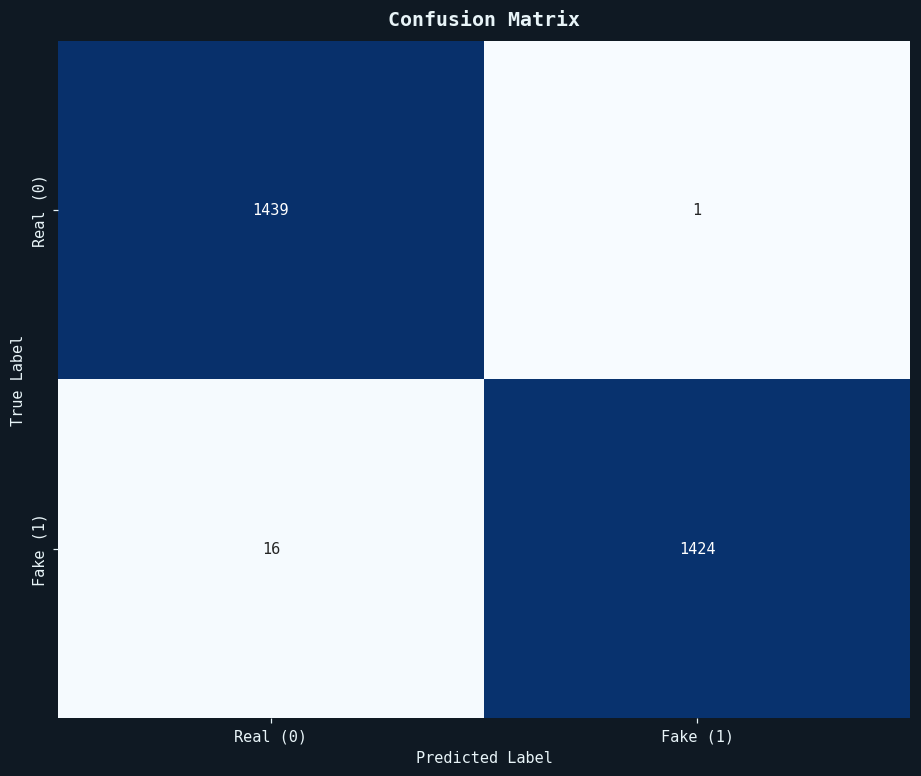

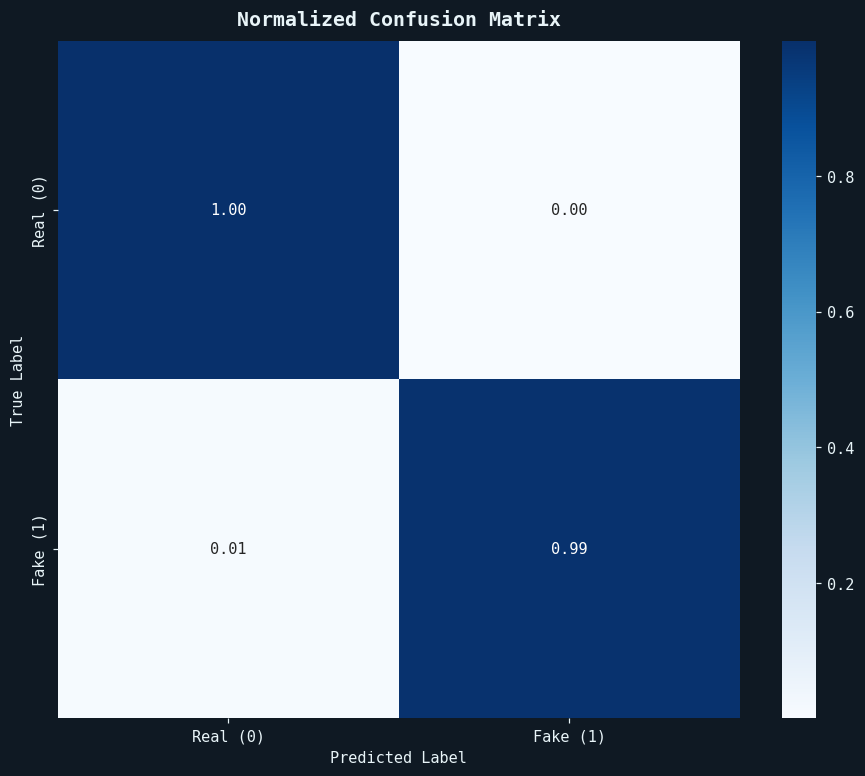

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      1440
        Fake       1.00      0.99      0.99      1440

    accuracy                           0.99      2880
   macro avg       0.99      0.99      0.99      2880
weighted avg       0.99      0.99      0.99      2880



In [ ]:
print("\nEvaluating model on test set...")

# Reload the best performing model to ensure it's not affected by tf.keras.backend.clear_session()
# The model 'best_model_f1.keras' was saved during the enhanced CNN training.
enhanced_cnn_model = load_model('best_model_f1.keras', compile=False)
enhanced_cnn_model.compile(
    optimizer='adam', loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)

# Re-split the original Mel spectrogram data to ensure correct X_test_cnn and y_test
# Load the saved mel spectrogram data and labels
X_mel_original = np.load("mel_data.npy")
y_mel_original = np.load("mel_labels.npy")

# Split data into train, validation, and test sets using the original Mel data
_, X_temp_original, _, y_temp_original = train_test_split(
    X_mel_original, y_mel_original, test_size=0.3, stratify=y_mel_original, random_state=42
)
_, X_test_cnn_correct, _, y_test_correct = train_test_split(
    X_temp_original, y_temp_original, test_size=0.5, stratify=y_temp_original, random_state=42
)

# Reshape y_test_correct to 2D
y_test_correct = y_test_correct.reshape(-1, 1)

test_loss, test_accuracy, test_f1 = enhanced_cnn_model.evaluate(X_test_cnn_correct, y_test_correct)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Predict on test set
y_pred_prob = enhanced_cnn_model.predict(X_test_cnn_correct)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = y_test_correct.astype(int)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.yticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.yticks([0.5, 1.5], ['Real (0)', 'Fake (1)'])
plt.show()

# Generate classification report
report = classification_report(y_true, y_pred, target_names=['Real', 'Fake'])
print("Classification Report:")
print(report)

# Analyze model performance on specific samples

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Analysis of Predictions:
Correctly classified real samples: 5
Correctly classified fake samples: 5
Incorrectly classified real samples (false positives): 1
Incorrectly classified fake samples (false negatives): 5


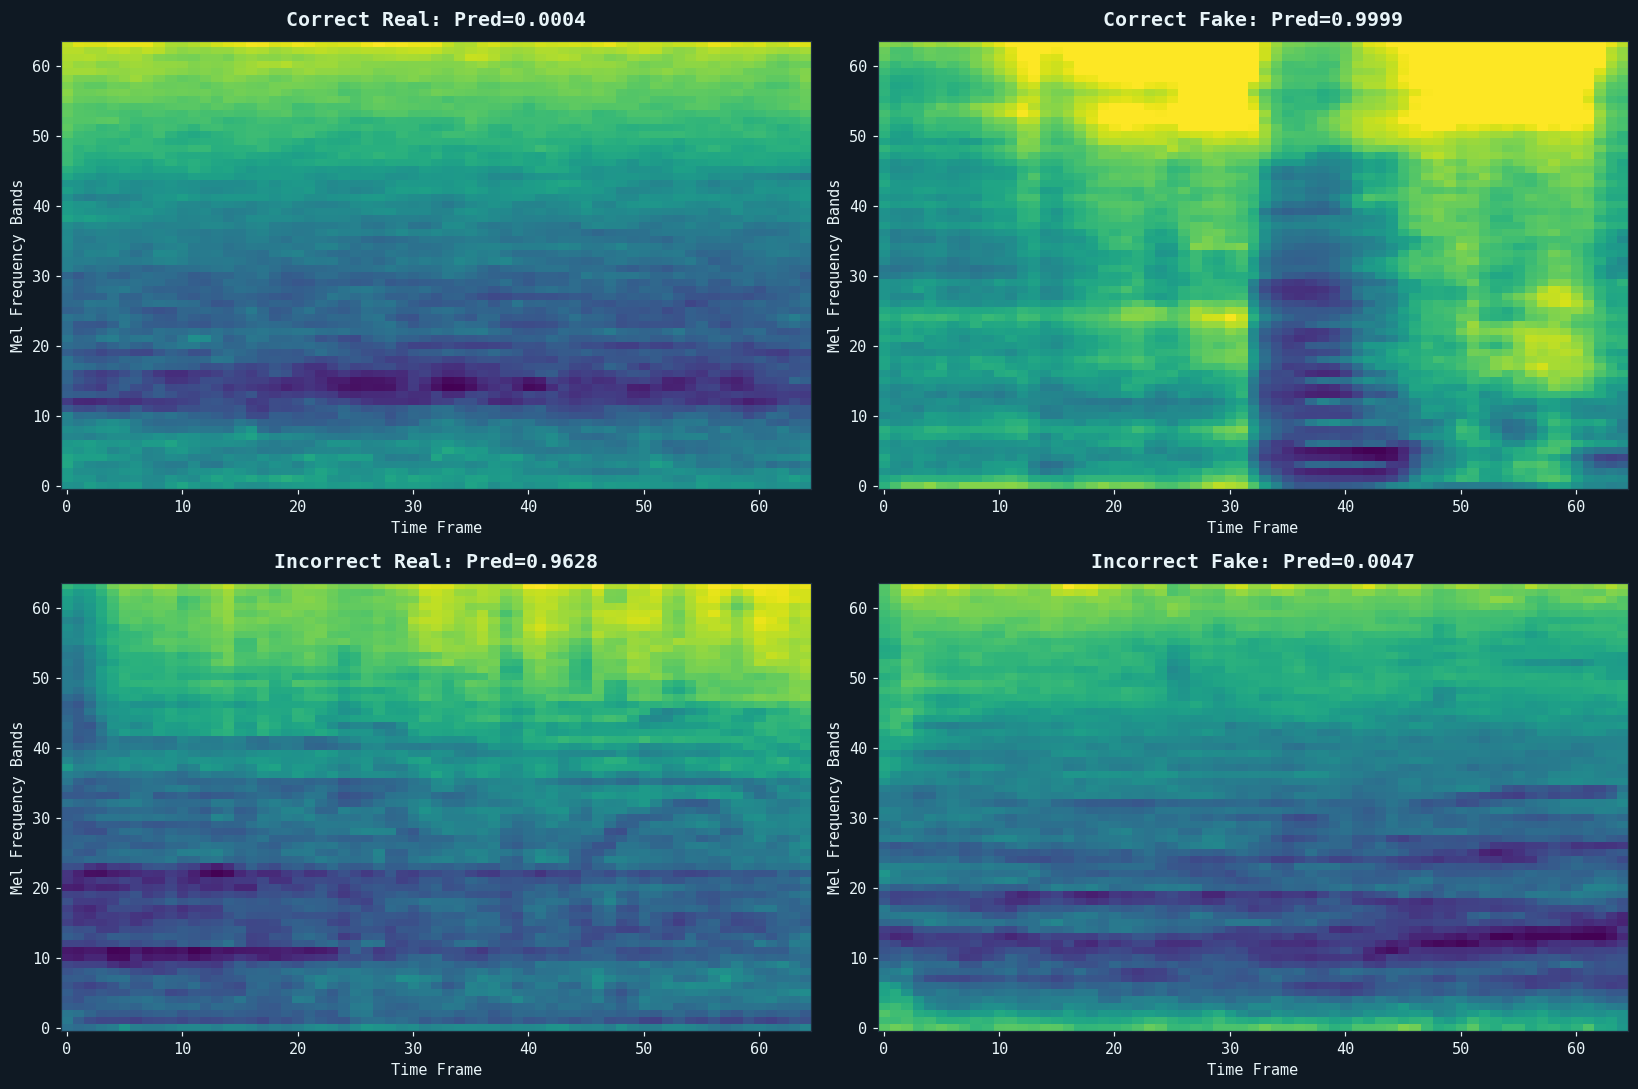

In [ ]:
# Analyze model performance on specific samples
def analyze_predictions(model, X_test, y_test, n_samples=5):
    """
    Analyze model predictions on specific test samples.
    Parameters:
    model: Trained model
    X_test: Test data
    y_test: Test labels
    n_samples: Number of samples to analyze per class
    """
    # Get predictions
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Find indices of correctly and incorrectly classified samples
    correct_indices = np.where(y_pred.flatten() == y_test.flatten())[0]
    incorrect_indices = np.where(y_pred.flatten() != y_test.flatten())[0]

    # Analyze correct predictions (both real and fake)
    real_correct = [i for i in correct_indices if y_test[i] == 0][:n_samples]
    fake_correct = [i for i in correct_indices if y_test[i] == 1][:n_samples]

    # Analyze incorrect predictions (both real and fake)
    real_incorrect = [i for i in incorrect_indices if y_test[i] == 0][:n_samples]
    fake_incorrect = [i for i in incorrect_indices if y_test[i] == 1][:n_samples]

    # Display results
    print("\nAnalysis of Predictions:")
    print(f"Correctly classified real samples: {len(real_correct)}")
    print(f"Correctly classified fake samples: {len(fake_correct)}")
    print(f"Incorrectly classified real samples (false positives): {len(real_incorrect)}")
    print(f"Incorrectly classified fake samples (false negatives): {len(fake_incorrect)}")

    # Plot some examples
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot a correctly classified real example
    if real_correct:
        idx = real_correct[0]
        axes[0, 0].imshow(X_test[idx, :, :, 0], aspect='auto', origin='lower')
        axes[0, 0].set_title(f"Correct Real: Pred={y_pred_prob[idx][0]:.4f}")
        axes[0, 0].set_ylabel("Mel Frequency Bands")
        axes[0, 0].set_xlabel("Time Frame")

    # Plot a correctly classified fake example
    if fake_correct:
        idx = fake_correct[0]
        axes[0, 1].imshow(X_test[idx, :, :, 0], aspect='auto', origin='lower')
        axes[0, 1].set_title(f"Correct Fake: Pred={y_pred_prob[idx][0]:.4f}")
        axes[0, 1].set_ylabel("Mel Frequency Bands")
        axes[0, 1].set_xlabel("Time Frame")

    # Plot an incorrectly classified real example (false positive)
    if real_incorrect:
        idx = real_incorrect[0]
        axes[1, 0].imshow(X_test[idx, :, :, 0], aspect='auto', origin='lower')
        axes[1, 0].set_title(f"Incorrect Real: Pred={y_pred_prob[idx][0]:.4f}")
        axes[1, 0].set_ylabel("Mel Frequency Bands")
        axes[1, 0].set_xlabel("Time Frame")

    # Plot an incorrectly classified fake example (false negative)
    if fake_incorrect:
        idx = fake_incorrect[0]
        axes[1, 1].imshow(X_test[idx, :, :, 0], aspect='auto', origin='lower')
        axes[1, 1].set_title(f"Incorrect Fake: Pred={y_pred_prob[idx][0]:.4f}")
        axes[1, 1].set_ylabel("Mel Frequency Bands")
        axes[1, 1].set_xlabel("Time Frame")

    plt.tight_layout()
    plt.show()

# Analyze specific predictions
analyze_predictions(enhanced_cnn_model, X_test_cnn, y_test)

# Model comparision

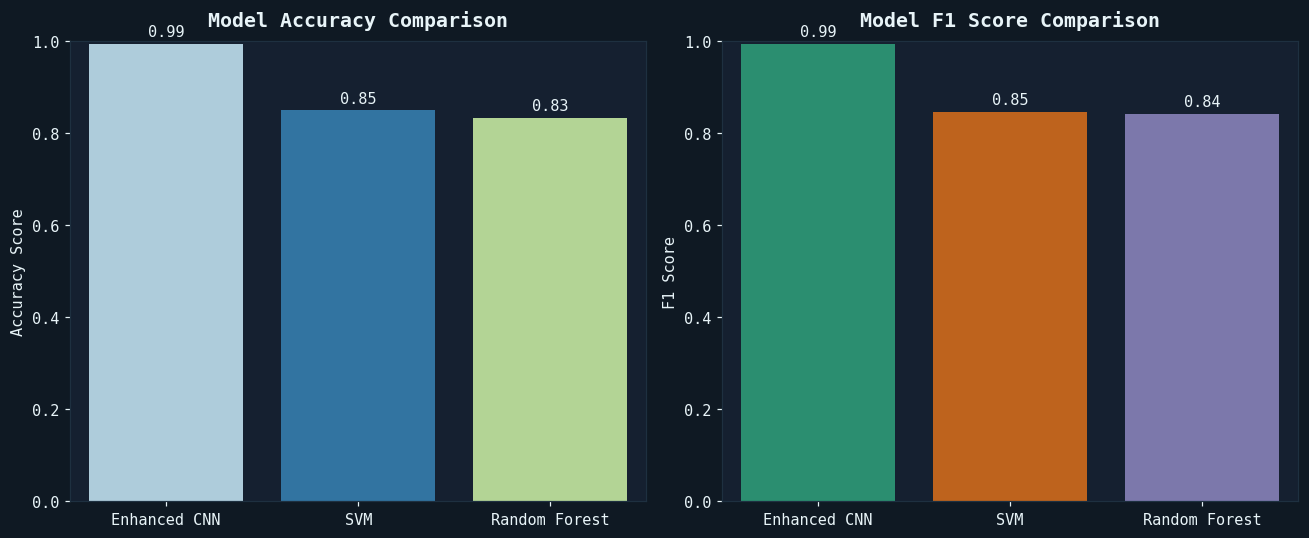

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Model names
models = ['Enhanced CNN', 'SVM', 'Random Forest']
# Scores (ensure these are defined in your previous code)
accuracy_scores = [test_accuracy, svm_accuracy, rf_accuracy]
f1_scores = [test_f1, svm_f1, rf_f1]
# Plot settings
plt.figure(figsize=(12, 5))
# Accuracy plot
plt.subplot(1, 2, 1)
sns.barplot(x=models, y=accuracy_scores, palette='Paired', hue=models, legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
for i, acc in enumerate(accuracy_scores):
    plt.text(i, acc + 0.01, f"{acc:.2f}"
    , ha='center', va='bottom')
# F1 Score plot
plt.subplot(1, 2, 2)
sns.barplot(x=models, y=f1_scores, palette='Dark2', hue=models, legend=False)
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for i, f1 in enumerate(f1_scores):
    plt.text(i, f1 + 0.01, f"{f1:.2f}"
    , ha='center', va='bottom')
plt.tight_layout()
plt.show()

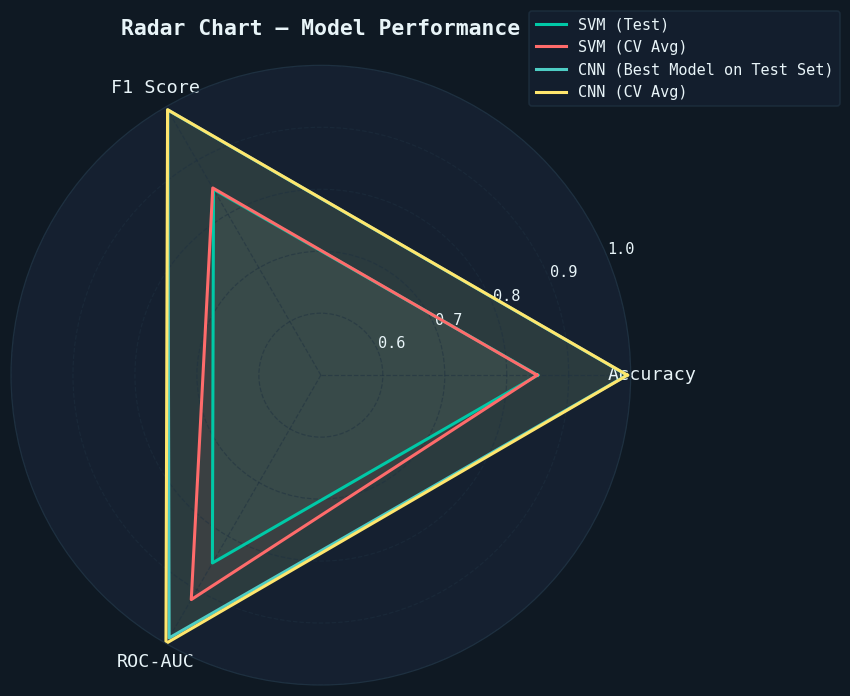

In [ ]:
# ── Radar / spider chart ──────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

cats   = ['Accuracy', 'F1 Score', 'ROC-AUC']
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['panel'])
ax.set_ylim(0.5, 1.0)

for i, (_, row) in enumerate(df_updated_results.iterrows()):
    values = [row['Accuracy'], row['F1 Score'], row['ROC AUC']]
    values += values[:1]
    c = BAR_PALETTE[i % len(BAR_PALETTE)]
    ax.plot(angles, values, lw=2, color=c, label=row['Model'])
    ax.fill(angles, values, alpha=0.08, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12, color=PALETTE['text'])
ax.yaxis.set_tick_params(labelcolor=PALETTE['text'])
ax.spines['polar'].set_color(PALETTE['grid'])
ax.set_title('Radar Chart — Model Performance', fontsize=14,
             color=PALETTE['text'], pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## Recurrent Neural Network (RNN) Models: GRU and LSTM

Given the sequential nature of audio data, Recurrent Neural Networks (RNNs) like GRUs and LSTMs are well-suited for processing Mel spectrograms. These models can capture temporal dependencies within the audio features.

First, we need to reshape our Mel spectrogram data `X_mel` to a format suitable for RNNs: `(samples, timesteps, features)`.

In [ ]:
from tensorflow.keras.layers import GRU, LSTM, Bidirectional
import numpy as np
import tensorflow as tf

# Reshape X_mel for RNN input: (samples, timesteps, features)
# Original shape: (samples, n_mels, num_timesteps, 1)
# Target shape:   (samples, num_timesteps, n_mels)

X_train_rnn = X_train_cnn.squeeze(axis=-1).transpose(0, 2, 1) # Remove channel dim, then swap n_mels and timesteps
X_val_rnn = X_val_cnn.squeeze(axis=-1).transpose(0, 2, 1)
X_test_rnn = X_test_cnn.squeeze(axis=-1).transpose(0, 2, 1)

print(f"RNN training set shape: {X_train_rnn.shape}")
print(f"RNN validation set shape: {X_val_rnn.shape}")
print(f"RNN test set shape: {X_test_rnn.shape}")

# Define common callbacks for RNN training
rnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
rnn_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Note: ModelCheckpoint for RNNs will use generic names, similar to CNN.
# We will evaluate these models directly after training and add their results to the comparison dataframe.


RNN training set shape: (13440, 65, 64)
RNN validation set shape: (2880, 65, 64)
RNN test set shape: (2880, 65, 64)


### GRU Model Definition and Training

In [ ]:
import tensorflow as tf # Ensure tf is imported
from tensorflow.keras.layers import Input # Ensure Input is imported

tf.keras.backend.clear_session()

def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.3),
        GRU(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

gru_model = build_gru_model(input_shape=X_train_rnn.shape[1:])
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)
gru_model.summary()

print("\nTraining GRU model...")
history_gru = gru_model.fit(
    X_train_rnn, y_train_tf,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_rnn, y_val_tf),
    callbacks=[rnn_early_stopping, rnn_reduce_lr],
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 65, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,545 (142.75 KB)

 Trainable params: 36,545 (142.75 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU model...
Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6162 - f1_score_metric: 0.6154 - loss: 0.6413 - val_accuracy: 0.7826 - val_f1_score_metric: 0.7659 - val_loss: 0.4853 - learning_rate: 0.0010
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8132 - f1_score_metric: 0.8065 - loss: 0.4296 - val_accuracy: 0.8538 - val_f1_score_metric: 0.8464 - val_loss: 0.3492 - learning_rate: 0.0010
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8577 - f1_score_metric: 0.8570 - loss: 0.3256 - val_accuracy: 0.8823 - val_f1_score_metric: 0.8861 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8825 - f1_score_metric: 0.8834 - loss: 0.2725 - val_accuracy: 0.9090 - val_f1_score_metric: 0.9084 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 5/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9003 - f1_score_metric: 0.9002 - loss: 0.2398 - val_accuracy: 0.9139 - val

### LSTM Model Definition and Training

In [ ]:
import tensorflow as tf # Ensure tf is imported
from tensorflow.keras.layers import Input # Ensure Input is imported

tf.keras.backend.clear_session()

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

lstm_model = build_lstm_model(input_shape=X_train_rnn.shape[1:])
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(name='f1_score_metric', threshold=0.5)]
)
lstm_model.summary()

print("\nTraining LSTM model...")
history_lstm = lstm_model.fit(
    X_train_rnn, y_train_tf,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_rnn, y_val_tf),
    callbacks=[rnn_early_stopping, rnn_reduce_lr],
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 65, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,617 (186.00 KB)

 Trainable params: 47,617 (186.00 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6583 - f1_score_metric: 0.6470 - loss: 0.6204 - val_accuracy: 0.6542 - val_f1_score_metric: 0.5074 - val_loss: 0.6633 - learning_rate: 0.0010
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7718 - f1_score_metric: 0.7728 - loss: 0.4922 - val_accuracy: 0.8163 - val_f1_score_metric: 0.8266 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8200 - f1_score_metric: 0.8241 - loss: 0.3966 - val_accuracy: 0.8660 - val_f1_score_metric: 0.8667 - val_loss: 0.3236 - learning_rate: 0.0010
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8400 - f1_score_metric: 0.8427 - loss: 0.3544 - val_accuracy: 0.8622 - val_f1_score_metric: 0.8593 - val_loss: 0.3321 - learning_rate: 0.0010
Epoch 5/50
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8691 - f1_score_metric: 0.8675 - loss: 0.3085
Epoch 5: ReduceLROnPlateau 

### Evaluation of GRU and LSTM Models

In [ ]:
import tensorflow as tf # Ensure tf is imported
from sklearn.metrics import roc_auc_score # Ensure roc_auc_score is imported

print("\nEvaluating GRU model on test set...")
gru_loss, gru_accuracy, gru_f1 = gru_model.evaluate(X_test_rnn, tf.cast(y_test, tf.float32), verbose=0)
print(f"GRU Test Accuracy: {gru_accuracy:.4f}")
print(f"GRU Test F1 Score: {gru_f1:.4f}")

print("\nEvaluating LSTM model on test set...")
lstm_loss, lstm_accuracy, lstm_f1 = lstm_model.evaluate(X_test_rnn, tf.cast(y_test, tf.float32), verbose=0)
print(f"LSTM Test Accuracy: {lstm_accuracy:.4f}")
print(f"LSTM Test F1 Score: {lstm_f1:.4f}")

# For ROC AUC, we need probabilities
y_pred_prob_gru = gru_model.predict(X_test_rnn, verbose=0).ravel()
gru_roc_auc = roc_auc_score(y_test, y_pred_prob_gru)

y_pred_prob_lstm = lstm_model.predict(X_test_rnn, verbose=0).ravel()
lstm_roc_auc = roc_auc_score(y_test, y_pred_prob_lstm)

print(f"GRU Test ROC-AUC: {gru_roc_auc:.4f}")
print(f"LSTM Test ROC-AUC: {lstm_roc_auc:.4f}")


Evaluating GRU model on test set...
GRU Test Accuracy: 0.9729
GRU Test F1 Score: 0.9727

Evaluating LSTM model on test set...
LSTM Test Accuracy: 0.6500
LSTM Test F1 Score: 0.4950
GRU Test ROC-AUC: 0.9970
LSTM Test ROC-AUC: 0.8269


## Updated Model Comparison with RNN Models


Updated Model Comparison:
| Model                        |   Accuracy |   F1 Score |   ROC AUC |
|:-----------------------------|-----------:|-----------:|----------:|
| SVM (Test)                   |   0.85     |   0.846416 |  0.85     |
| SVM (CV Avg)                 |   0.849    |   0.848871 |  0.9182   |
| CNN (Best Model on Test Set) |   0.994097 |   0.994066 |  0.98966  |
| CNN (CV Avg)                 |   0.994687 |   0.994679 |  0.999865 |
| GRU (Test)                   |   0.972917 |   0.972689 |  0.996997 |
| LSTM (Test)                  |   0.65     |   0.49499  |  0.826907 |


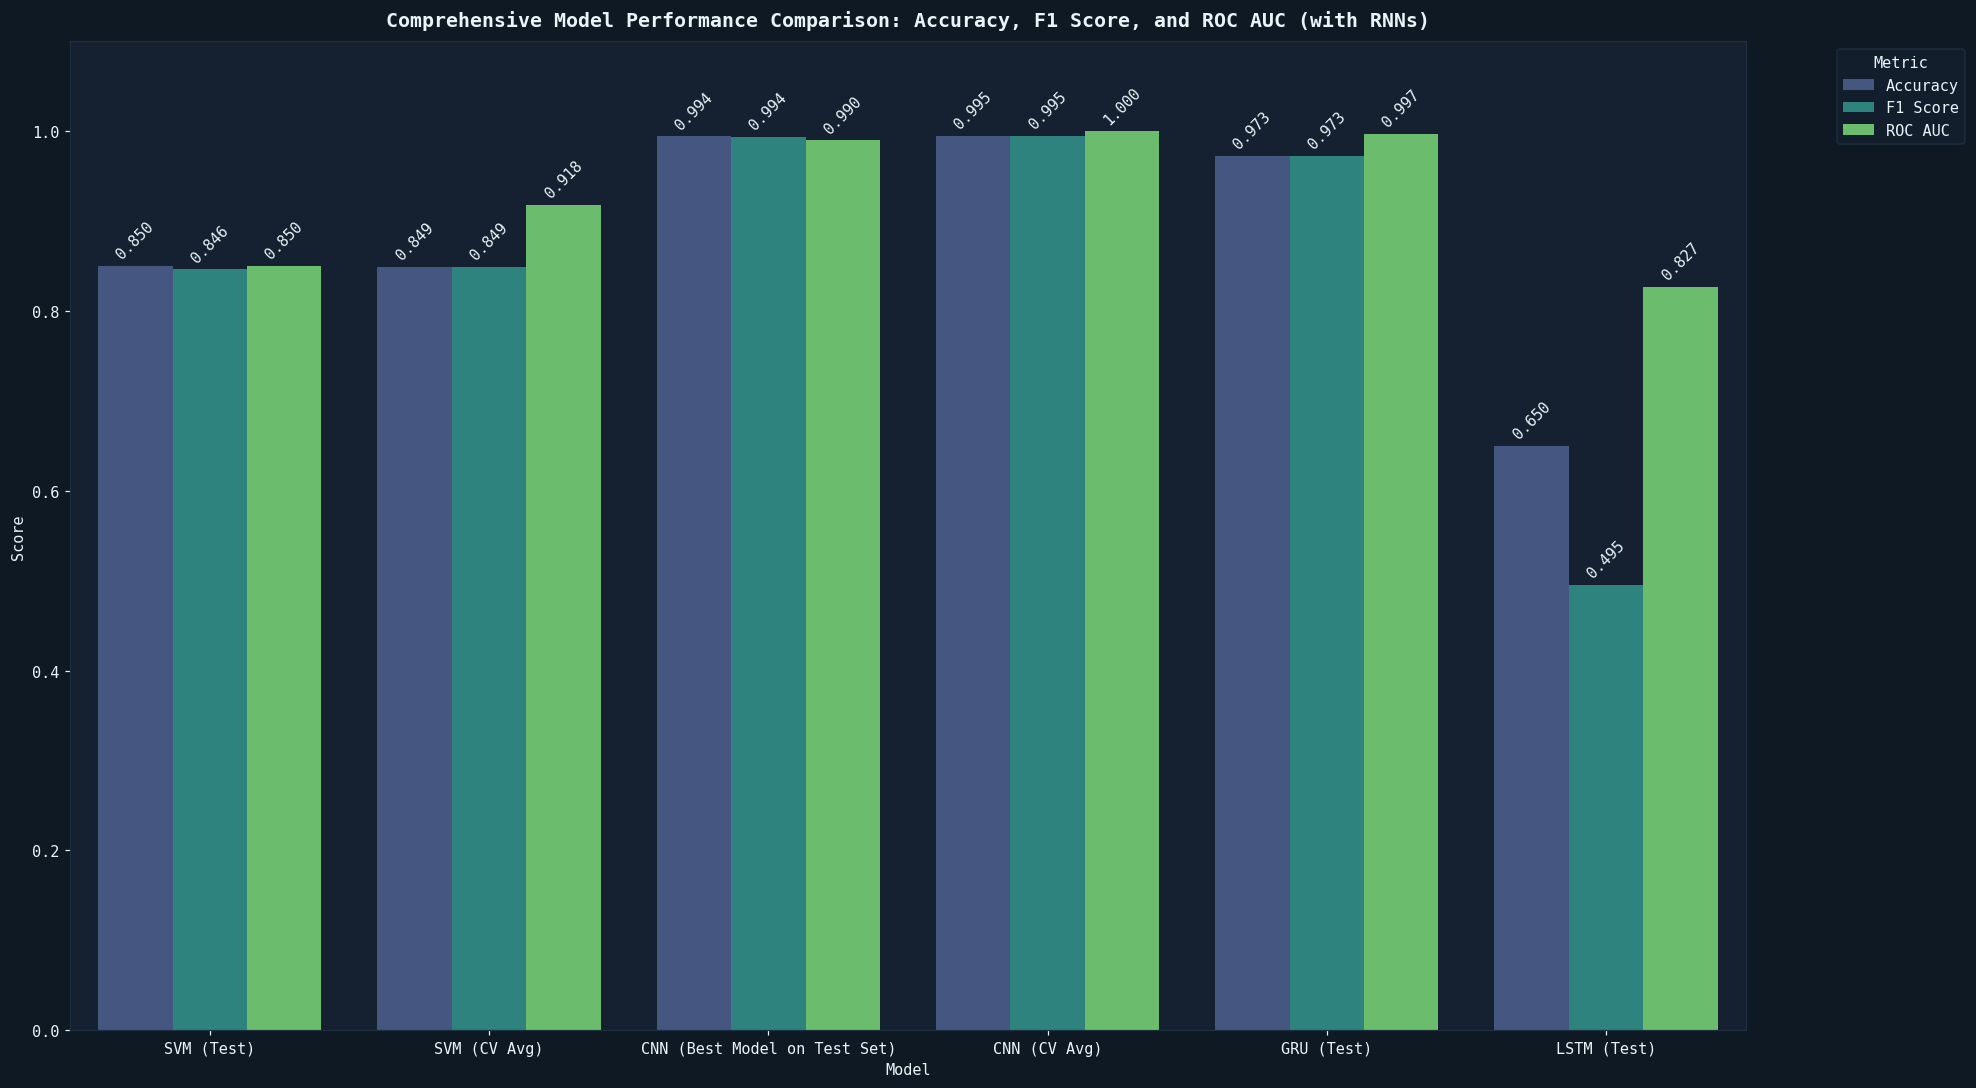

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure cnn_metrics, svm_accuracy, svm_f1, roc_auc, cv_acc, cv_scores, cv_roc, cnn_cv_accuracy_scores, etc. are defined from previous cells

updated_results = {
    "Model": [
        "SVM (Test)", "SVM (CV Avg)",
        "CNN (Best Model on Test Set)", "CNN (CV Avg)",
        "GRU (Test)", "LSTM (Test)"
    ],
    "Accuracy": [
        svm_accuracy, cv_acc.mean(),
        cnn_metrics[1],
        np.mean(cnn_cv_accuracy_scores),
        gru_accuracy,
        lstm_accuracy
    ],
    "F1 Score": [
        svm_f1, cv_scores.mean(),
        cnn_metrics[2],
        np.mean(cnn_cv_f1_scores),
        gru_f1,
        lstm_f1
    ],
    "ROC AUC": [
        roc_auc, cv_roc.mean(),
        roc_auc_cnn,
        np.mean(cnn_cv_roc_auc_scores),
        gru_roc_auc,
        lstm_roc_auc
    ]
}

df_updated_results = pd.DataFrame(updated_results)
print("\nUpdated Model Comparison:")
print(df_updated_results.to_markdown(index=False))

# Visualize the updated comparison
df_melted_updated = df_updated_results.melt(id_vars=['Model'], var_name='Metric', value_name='Value')

plt.figure(figsize=(18, 10))
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted_updated, palette='viridis')
plt.title('Comprehensive Model Performance Comparison: Accuracy, F1 Score, and ROC AUC (with RNNs)')
plt.ylabel('Score')
plt.ylim(0, 1.1) # Extend y-limit slightly above 1 for labels

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3, rotation=45)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


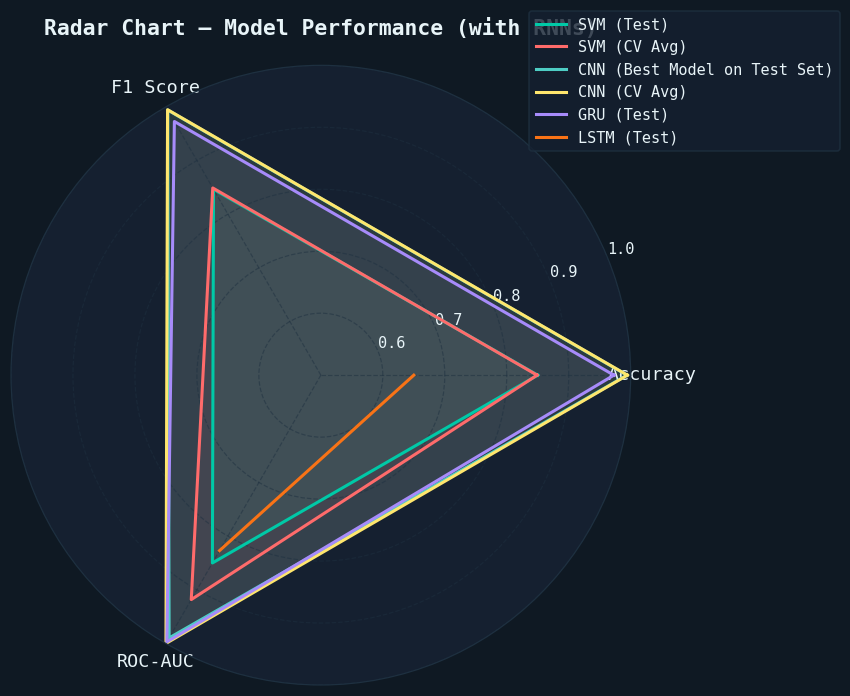

In [ ]:
# ── Radar / spider chart ────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
import numpy as np # Ensure numpy is imported

cats   = ['Accuracy', 'F1 Score', 'ROC-AUC']
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['panel'])
ax.set_ylim(0.5, 1.0)

# Ensure BAR_PALETTE has enough colors or adjust as needed
if len(BAR_PALETTE) < len(df_updated_results):
    extended_palette = BAR_PALETTE + sns.color_palette('tab10', len(df_updated_results) - len(BAR_PALETTE))
else:
    extended_palette = BAR_PALETTE

for i, (_, row) in enumerate(df_updated_results.iterrows()):
    values = [row['Accuracy'], row['F1 Score'], row['ROC AUC']]
    values += values[:1]
    c = extended_palette[i % len(extended_palette)] # Use extended palette
    ax.plot(angles, values, lw=2, color=c, label=row['Model'])
    ax.fill(angles, values, alpha=0.08, color=c)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12, color=PALETTE['text'])
ax.yaxis.set_tick_params(labelcolor=PALETTE['text'])
ax.spines['polar'].set_color(PALETTE['grid'])
ax.set_title('Radar Chart — Model Performance (with RNNs)', fontsize=14,
             color=PALETTE['text'], pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()


## Comprehensive Performance Comparison Between Model Training Rounds

This section consolidates the performance metrics from both sets of models:

1.  **Initial Augmented Models**: These were trained using `n_samples_per_class = 60` during Mel-spectrogram extraction for CNN/RNNs, and `samples_per_file = 30` for MFCC-based traditional ML models.
2.  **Refined Augmented Models**: These models benefited from a larger feature set, using `n_samples_per_class = 200` for CNN/RNN Mel-spectrograms and `samples = 100` for MFCC-based traditional ML. These represent the final evaluations after the second, more extensive feature extraction.

Note that ROC AUC was not explicitly calculated for all models in the initial augmented round or for the refined Random Forest model within the notebook's scope, so those entries will appear as NaN.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Initial Augmented Models (from cell 1885eb4f) ---
# The 'aug_results' DataFrame already exists in the notebook's state
# Renaming models for clarity in the combined comparison
df_initial_augmented_results = aug_results.copy()
df_initial_augmented_results['Model'] = df_initial_augmented_results['Model'].apply(lambda x: x.replace('(Augmented)', '(Initial Aug. - Test)'))
df_initial_augmented_results['ROC AUC'] = np.nan # ROC AUC was not reported for these

# --- 2. Refined Augmented Models ---
# It includes SVM (Test), SVM (CV Avg), CNN (Test), CNN (CV Avg), GRU (Test), LSTM (Test)

df_refined_results = df_updated_results.copy()
# Rename models for clarity
df_refined_results['Model'] = df_refined_results['Model'].str.replace('SVM (Test)', 'SVM (Refined Aug. - Test)')
df_refined_results['Model'] = df_refined_results['Model'].str.replace('SVM (CV Avg)', 'SVM (Refined Aug. - CV Avg)')
df_refined_results['Model'] = df_refined_results['Model'].str.replace('CNN (Best Model on Test Set)', 'CNN (Refined Aug. - Test)')
df_refined_results['Model'] = df_refined_results['Model'].str.replace('CNN (CV Avg)', 'CNN (Refined Aug. - CV Avg)')
df_refined_results['Model'] = df_refined_results['Model'].str.replace('GRU (Test)', 'GRU (Refined Aug. - Test)')
df_refined_results['Model'] = df_refined_results['Model'].str.replace('LSTM (Test)', 'LSTM (Refined Aug. - Test)')


# Add the Refined Random Forest explicitly
rf_refined_row = pd.DataFrame({
    'Model': ['Random Forest (Refined Aug. - Test)'],
    'Accuracy': [rf_accuracy],
    'F1 Score': [rf_f1],
    'ROC AUC': [np.nan] # ROC AUC not explicitly calculated for this model in notebook
})

# Combine with the refined results
df_refined_results = pd.concat([df_refined_results, rf_refined_row], ignore_index=True)

# --- 3. Combine both sets of results ---
combined_comparison_df = pd.concat([df_initial_augmented_results, df_refined_results], ignore_index=True)

print("\nComprehensive Model Performance Comparison:")
display(combined_comparison_df)




Comprehensive Model Performance Comparison:


,Model,Accuracy,F1 Score,ROC AUC
0,CNN (Initial Aug. - Test),0.980324,0.980347,NaN
1,GRU (Initial Aug. - Test),0.934028,0.936737,NaN
2,LSTM (Initial Aug. - Test),0.643519,0.711610,NaN
3,SVM (Initial Aug. - Test),0.813657,0.806258,NaN
4,Random Forest (Initial Aug. - Test),0.836806,0.838488,NaN
5,SVM (Refined Aug. - Test),0.850000,0.846416,0.850000
6,SVM (Refined Aug. - CV Avg),0.849000,0.848871,0.918200
7,CNN (Refined Aug. - Test),0.994097,0.994066,0.989660
8,CNN (Refined Aug. - CV Avg),0.994687,0.994679,0.999865
9,GRU (Refined Aug. - Test),0.972917,0.972689,0.996997


In [ ]:
print("\n" + "═" * 55)
print(" 🎙️  VOICE AUTHENTICITY DETECTION — FINAL RESULTS (with RNNs)")
print("═" * 55)
print(f"{'Model':<28} {'Accuracy':>9} {'F1':>9} {'ROC-AUC':>9}")
print("─" * 61) # Adjusted length for longer model names

# Re-find the best model after adding RNNs
best_f1_score = df_updated_results['F1 Score'].max()

for _, row in df_updated_results.iterrows():
    marker = " ⬅  BEST" if row['F1 Score'] == best_f1_score else ""
    print(f"{row['Model']:<28} {row['Accuracy']:>9.4f} {row['F1 Score']:>9.4f} {row['ROC AUC']:>9.4f}{marker}")
print("═" * 61)



═══════════════════════════════════════════════════════
 🎙️  VOICE AUTHENTICITY DETECTION — FINAL RESULTS (with RNNs)
═══════════════════════════════════════════════════════
Model                         Accuracy        F1   ROC-AUC
─────────────────────────────────────────────────────────────
SVM (Test)                      0.8500    0.8464    0.8500
SVM (CV Avg)                    0.8490    0.8489    0.9182
CNN (Best Model on Test Set)    0.9941    0.9941    0.9897
CNN (CV Avg)                    0.9947    0.9947    0.9999 ⬅  BEST
GRU (Test)                      0.9729    0.9727    0.9970
LSTM (Test)                     0.6500    0.4950    0.8269
═════════════════════════════════════════════════════════════


In [ ]:
best_cnn_model = load_model("best_model_f1.keras", compile=False)
best_cnn_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy', tf.keras.metrics.F1Score(threshold=0.5)])
cnn_metrics = best_cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print("\nBest CNN on Test Set:")
print(f"CNN Accuracy: {cnn_metrics[1]:.4f}")
print(f"CNN F1 Score: {cnn_metrics[2]:.4f}")


Best CNN on Test Set:
CNN Accuracy: 0.9941
CNN F1 Score: 0.9941


In [ ]:
results = {
"Model": ["SVM (Test)", "SVM (CV Avg)", "CNN (Best Model)"],
"Accuracy": [svm_accuracy, cv_acc.mean(), cnn_metrics[1]],
"F1 Score": [svm_f1, cv_scores.mean(), cnn_metrics[2]],
"ROC AUC": [roc_auc, cv_roc.mean(), roc_auc_cnn]
}
import pandas as pd
df_results = pd.DataFrame(results)
print("\n Model Comparison:")
print(df_results.to_markdown(index=False))


 Model Comparison:
| Model            |   Accuracy |   F1 Score |   ROC AUC |
|:-----------------|-----------:|-----------:|----------:|
| SVM (Test)       |   0.85     |   0.846416 |   0.85    |
| SVM (CV Avg)     |   0.849    |   0.848871 |   0.9182  |
| CNN (Best Model) |   0.994097 |   0.994066 |   0.98966 |


# Using available CSV file

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import seaborn as sns
# ----------------------------
# 1. Load and Preprocess Data
# ----------------------------
# Load CSV
df = pd.read_csv('/content/extracted_files/KAGGLE/DATASET-balanced.csv') # Replace with your CSV
print("Data Head:\n"
, df.head())
# Encode labels (FAKE -> 1, REAL -> 0)
df['LABEL'] = df['LABEL'].map({'FAKE': 1, 'REAL': 0})
# Separate features and labels
X = df.drop('LABEL', axis=1).values
y = df['LABEL'].values
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
# ----------------------------
# 2. Train Traditional ML Models
# ----------------------------
# SVM
svm_model = SVC(kernel='rbf', C=3, probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
# ----------------------------
# 3. Train CNN (Requires reshaping features)
# ----------------------------
# Reshape features into 2D "images" (dummy example; adjust as needed)
# Since your data is 1D, we'll artificially create a 2D structure (e.g.,
n_features = X_train.shape[1] # Number of features (e.g., 26 in your CSV
# Find the closest square dimensions (e.g., 5x5=25 for 26 features)
n_rows = int(np.sqrt(n_features)) # Start with square root
n_cols = n_rows
# Adjust if needed (e.g., 26 → 5x6)
while n_rows * n_cols < n_features:
    n_cols += 1
padding = n_rows * n_cols - n_features
print(f"Reshaping {n_features} features to {n_rows}x{n_cols} (padding: {padding}")
# Pad features if not perfectly divisible
if padding > 0:
    X_train_padded = np.pad(X_train, ((0, 0), (0, padding)), mode='constant')
    X_test_padded = np.pad(X_test, ((0, 0), (0, padding)), mode='constant')
else:
    X_train_padded = X_train
    X_test_padded = X_test
# Reshape to (samples, height, width, channels)
X_train_cnn = X_train_padded.reshape(-1, n_rows, n_cols, 1)
X_test_cnn = X_test_padded.reshape(-1, n_rows, n_cols, 1)
print("Shapes:")
print(f"Train: {X_train_cnn.shape}, Test: {X_test_cnn.shape}")
# Define a simple CNN (for illustration; not optimal for 1D features)
def build_cnn_model():
    model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(n_rows, n_cols, 1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
cnn_model = build_cnn_model()
history = cnn_model.fit(
X_train_cnn, y_train,
epochs=20,
batch_size=32,
validation_data=(X_test_cnn, y_test),
verbose=1
)
# Evaluate CNN
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
cnn_f1 = f1_score(y_test, y_pred_cnn)
# ----------------------------
# 4. Compare Models
# ----------------------------
results = pd.DataFrame({
'Model': ['SVM', 'Random Forest', 'CNN (Artificial 2D)'] ,
'Accuracy': [svm_accuracy, rf_accuracy, cnn_accuracy],
'F1-Score': [svm_f1, rf_f1, cnn_f1]
})
print("\n=== Model Comparison ===")
print(results)

Data Head:
    chroma_stft       rms  spectral_centroid  spectral_bandwidth      rolloff  \
0     0.338055  0.027948        2842.948867         4322.916759  6570.586186   
1     0.443766  0.037838        2336.129597         3445.777044  3764.949874   
2     0.302528  0.056578        2692.988386         2861.133180  4716.610271   
3     0.319933  0.031504        2241.665382         3503.766175  3798.641521   
4     0.420055  0.016158        2526.069123         3102.659519  5025.077899   

   zero_crossing_rate       mfcc1       mfcc2      mfcc3      mfcc4  ...  \
0            0.041050 -462.169586   90.311272  19.073769  24.046888  ...   
1            0.047730 -409.413422  120.348808  -7.161531   5.114784  ...   
2            0.080342 -318.996033  120.490273 -24.625771  23.891073  ...   
3            0.047180 -404.636749  136.320908   2.308172  -3.907071  ...   
4            0.051905 -410.497925  152.731400 -18.266771  51.993462  ...   

     mfcc12    mfcc13    mfcc14    mfcc15    mfcc1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7003 - loss: 2.1156 - val_accuracy: 0.7844 - val_loss: 1.0004
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7582 - loss: 0.9174 - val_accuracy: 0.8413 - val_loss: 0.4457
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7791 - loss: 0.8205 - val_accuracy: 0.8209 - val_loss: 0.4977
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7871 - loss: 0.8507 - val_accuracy: 0.5870 - val_loss: 1.7313
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8127 - loss: 0.6511 - val_accuracy: 0.8196 - val_loss: 0.8631
Epoch 6/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8187 - loss: 0.6621 - val_accuracy: 0.8400 - val_loss: 0.3981
Epoch 7/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8233 - loss: 0.5970 - val_accuracy: 0.8472 - val_loss: 0.5189
Epoch 8/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8465 - loss: 0.4983 - val_accuracy: 0.8739 - val_

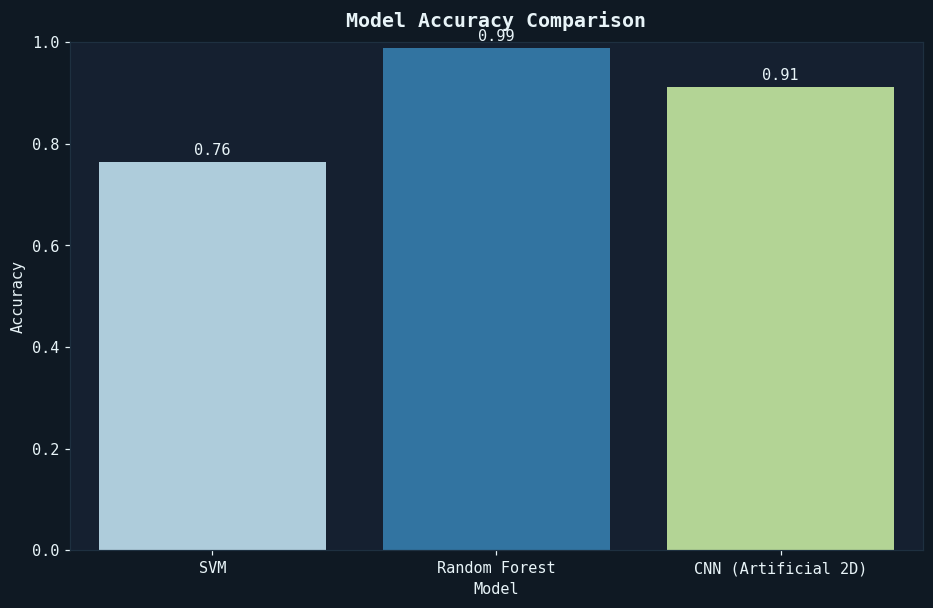

In [ ]:
# Plot results
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=results, palette='Paired', hue='Model', legend=False)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)
plt.show()

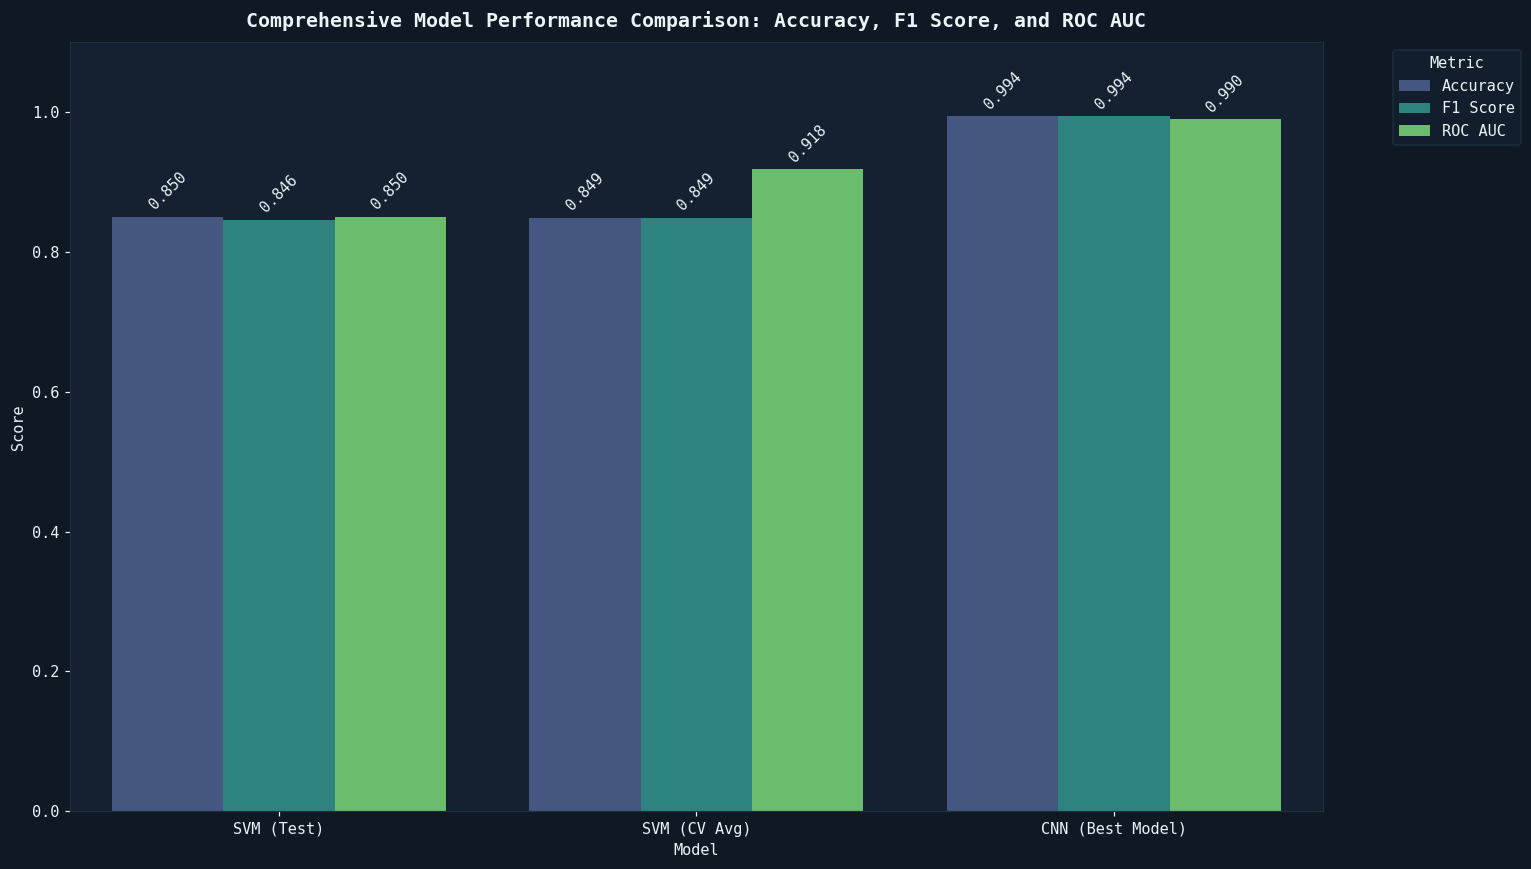


Visual Comparison of All Models and Metrics:


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the DataFrame to have 'Metric' and 'Value' columns for grouped bar chart
df_melted = df_results.melt(id_vars=['Model'], var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette='viridis')
plt.title('Comprehensive Model Performance Comparison: Accuracy, F1 Score, and ROC AUC')
plt.ylabel('Score')
plt.ylim(0, 1.1) # Extend y-limit slightly above 1 for labels

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', padding=3, rotation=45)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nVisual Comparison of All Models and Metrics:")

In [ ]:
print("\n" + "═" * 55)
print(" 🎙️  VOICE AUTHENTICITY DETECTION — FINAL RESULTS")
print("═" * 55)
print(f"{'Model':<22} {'Accuracy':>9} {'F1':>9} {'ROC-AUC':>9}")
print("─" * 55)
for _, row in df_updated_results.iterrows():
    marker = " ⬅  BEST" if row['F1 Score'] == df_updated_results['F1 Score'].max() else ""
    print(f"{row['Model']:<22} {row['Accuracy']:>9.4f} {row['F1 Score']:>9.4f} {row['ROC AUC']:>9.4f}{marker}")
print("═" * 55)


═══════════════════════════════════════════════════════
 🎙️  VOICE AUTHENTICITY DETECTION — FINAL RESULTS
═══════════════════════════════════════════════════════
Model                   Accuracy        F1   ROC-AUC
───────────────────────────────────────────────────────
SVM (Test)                0.8500    0.8464    0.8500
SVM (CV Avg)              0.8490    0.8489    0.9182
CNN (Best Model on Test Set)    0.9941    0.9941    0.9897
CNN (CV Avg)              0.9947    0.9947    0.9999 ⬅  BEST
GRU (Test)                0.9729    0.9727    0.9970
LSTM (Test)               0.6500    0.4950    0.8269
═══════════════════════════════════════════════════════
